script to extract the variant with the best ref2015 score

In [1]:
import csv
from pathlib import Path

# ===== USER SETTINGS =====
INPUT_FOLDER = Path("output/sorted_output")   # folder containing CSV files
EXTRA_CSV = None                   # optional extra CSV file path
OUTPUT_FILE = "correct_variant_performance.csv"
# =========================


def extract_first_data_row(csv_path):
    with open(csv_path, "r", newline="") as f:
        reader = csv.DictReader(f)

        try:
            row = next(reader)  # first data row after header
        except StopIteration:
            return None

        # Use filename (without .csv) as variant name
        variant_name = csv_path.stem

        # Remove "sorted_" prefix if present
        variant_name = variant_name.removeprefix("sorted_")

        row["variant_name"] = variant_name

        return row


# Collect CSV files
csv_files = list(INPUT_FOLDER.glob("*.csv"))

if EXTRA_CSV is not None:
    csv_files.append(Path(EXTRA_CSV))

all_rows = []

for csv_file in csv_files:
    row = extract_first_data_row(csv_file)

    if row:
        all_rows.append(row)
        print(f"Processed: {csv_file.name}")
    else:
        print(f"Skipped empty file: {csv_file.name}")

if not all_rows:
    print("No valid rows found.")
else:
    # Put variant_name first
    fieldnames = ["variant_name"] + [
        key for key in all_rows[0].keys()
        if key != "variant_name"
    ]

    with open(OUTPUT_FILE, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)

        writer.writeheader()
        writer.writerows(all_rows)

    print(f"\nSaved combined CSV to: {OUTPUT_FILE}")

Processed: sorted_BFD-M3_Cheng3.csv
Processed: sorted_ReBALmat-FLS-V2.csv
Processed: sorted_BFD-BFD-M1.csv
Processed: sorted_BFD-M3_Cheng2.csv
Processed: sorted_BFD-M3_Cheng8.csv
Processed: sorted_ReBAL-ReBALwid.csv
Processed: sorted_BFD-M4_M4.csv
Processed: sorted_PfBAL-Des1.csv
Processed: sorted_BFD-M3_Cheng1.csv
Processed: sorted_BFD-M3_Cheng6.csv
Processed: sorted_BFD-M3_BFD-M4.csv
Processed: sorted_M5_M6.csv
Processed: sorted_BFD-M3_Cheng7.csv
Processed: sorted_BFD-M3_Cheng4.csv
Processed: sorted_M4_M5.csv
Processed: sorted_BFD-M3_Cheng5.csv
Processed: sorted_BFD-M3_Cheng9.csv
Processed: sorted_ReBAL-ReBALmat.csv
Processed: sorted_ReBALmat-FLS-V1.csv
Processed: sorted_FLS-FLSM3.csv
Processed: sorted_ReBALmat-FLS-V4.csv
Processed: sorted_BFD-M1_BFD-M2.csv
Processed: sorted_BFD-M2_BFD-M3.csv
Processed: sorted_BFD-M3_Cheng10.csv
Processed: sorted_ReBALmat-FLS-V3.csv
Processed: sorted_Des1-FLS.csv
Processed: sorted_ReBALmat-FLS-V5.csv

Saved combined CSV to: correct_variant_performanc

line graph

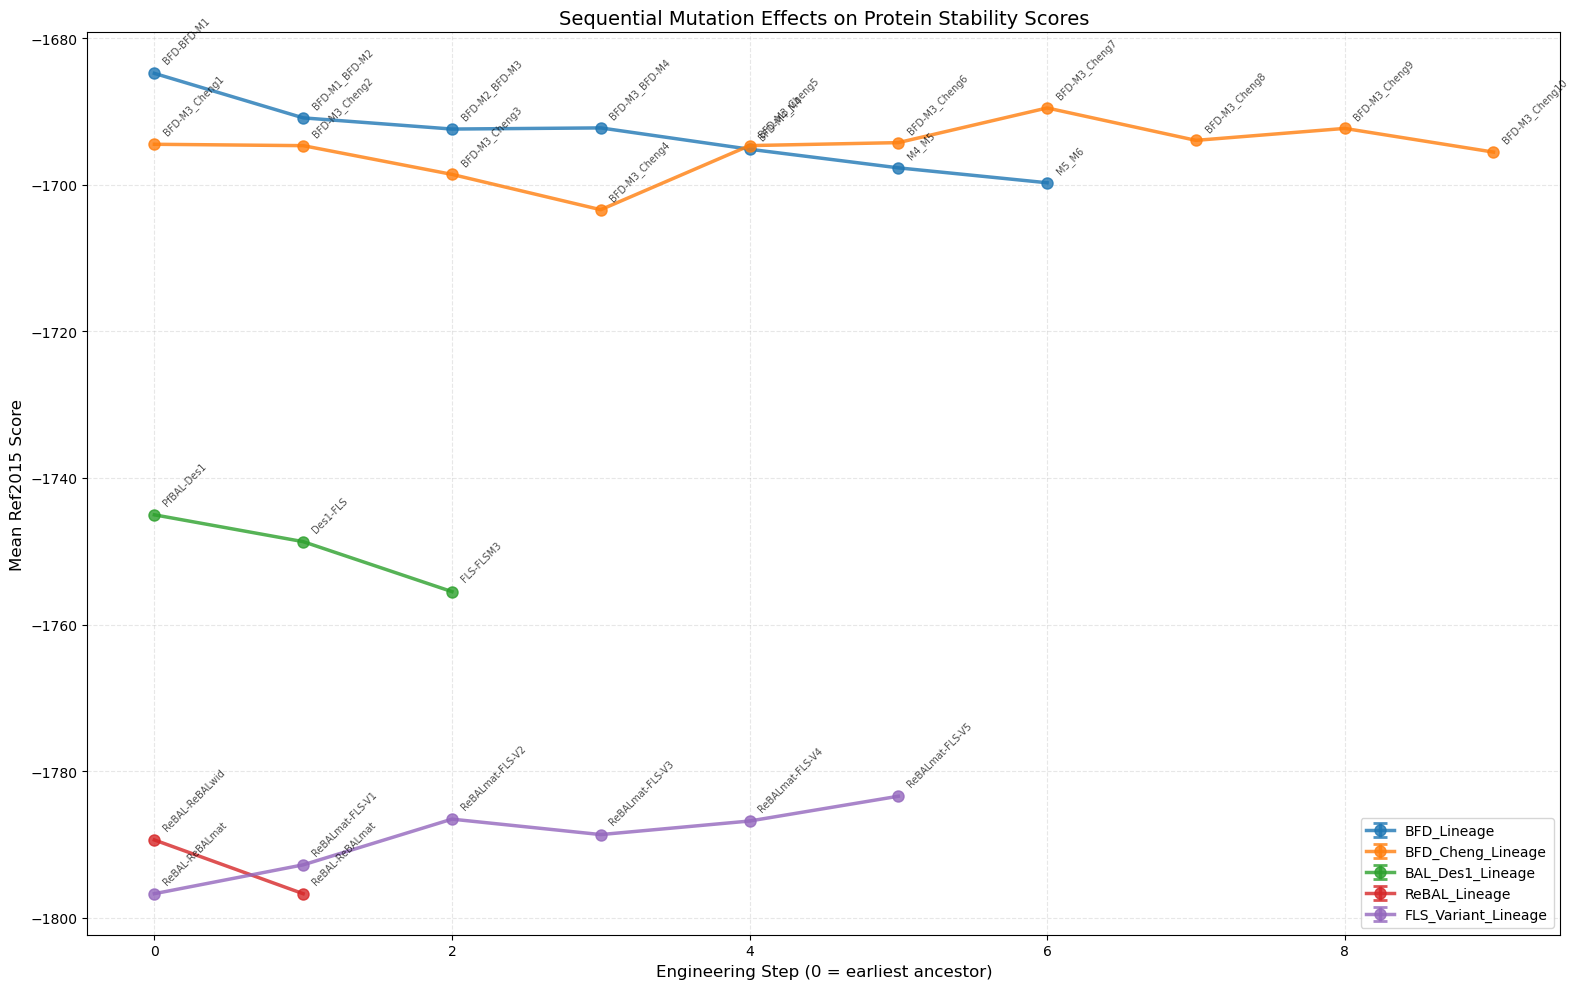


=== Lineage Summary ===


BFD_Lineage:
  BFD-BFD-M1: -1684.80 ± nan (n=1)
  BFD-M1_BFD-M2: -1690.87 ± nan (n=1)
    ↓ Change: -6.07
  BFD-M2_BFD-M3: -1692.40 ± nan (n=1)
    ↓ Change: -1.53
  BFD-M3_BFD-M4: -1692.24 ± nan (n=1)
    ↑ Change: +0.16
  BFD-M4_M4: -1695.15 ± nan (n=1)
    ↓ Change: -2.91
  M4_M5: -1697.69 ± nan (n=1)
    ↓ Change: -2.54
  M5_M6: -1699.73 ± nan (n=1)
    ↓ Change: -2.04

BFD_Cheng_Lineage:
  BFD-M3_Cheng1: -1694.48 ± nan (n=1)
  BFD-M3_Cheng2: -1694.66 ± nan (n=1)
    ↓ Change: -0.19
  BFD-M3_Cheng3: -1698.59 ± nan (n=1)
    ↓ Change: -3.92
  BFD-M3_Cheng4: -1703.41 ± nan (n=1)
    ↓ Change: -4.82
  BFD-M3_Cheng5: -1694.66 ± nan (n=1)
    ↑ Change: +8.75
  BFD-M3_Cheng6: -1694.25 ± nan (n=1)
    ↑ Change: +0.41
  BFD-M3_Cheng7: -1689.52 ± nan (n=1)
    ↑ Change: +4.73
  BFD-M3_Cheng8: -1693.94 ± nan (n=1)
    ↓ Change: -4.42
  BFD-M3_Cheng9: -1692.31 ± nan (n=1)
    ↑ Change: +1.63
  BFD-M3_Cheng10: -1695.55 ± nan (n=1)
    ↓ Change: -3.23

BAL_Des1_Lineag

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load your CSV
df = pd.read_csv("correct_variant_performance.csv")
df["score"] = pd.to_numeric(df["score"], errors="coerce")
df = df.dropna(subset=["score"])

# Calculate mean scores per variant (averaging across replicates)
variant_scores = df.groupby('variant_name')['score'].agg(['mean', 'std', 'count']).reset_index()

# Define evolutionary paths based on your actual sequential derivation
evolutionary_paths = {
    'BFD_Lineage': [
        'BFD-BFD-M1',           # W86R+N87T (ancestor)
        'BFD-M1_BFD-M2',        # +L109G+L110E
        'BFD-M2_BFD-M3',        # +A460M
        'BFD-M3_BFD-M4',        # +H281V+Q282F
        'BFD-M4_M4',            # V281Y+F282Q (mutation at position 281 and 282)
        'M4_M5',                # +S26F
        'M5_M6'                 # G109S
    ],
    'BFD_Cheng_Lineage': [
        'BFD-M3_Cheng1',        # S26F (branch from BFD-M3)
        'BFD-M3_Cheng2',        # G109I
        'BFD-M3_Cheng3',        # S236L
        'BFD-M3_Cheng4',        # S236F
        'BFD-M3_Cheng5',        # H281Y
        'BFD-M3_Cheng6',        # C398A
        'BFD-M3_Cheng7',        # C398M
        'BFD-M3_Cheng8',        # G401L
        'BFD-M3_Cheng9',        # G401H
        'BFD-M3_Cheng10'        # G401Y
    ],
    'BAL_Des1_Lineage': [
        'PfBAL-Des1',           # A28I+A394G+G419N+A480W (ancestor)
        'Des1-FLS',             # +W89R+L90T+R188H
        'FLS-FLSM3'             # I28L+T90L+N283H (note: I28L instead of A28I)
    ],
    'ReBAL_Lineage': [
        'ReBAL-ReBALwid',       # Q112A+E394A+S416G+T479A (ancestor)
        'ReBAL-ReBALmat'        # Q112L+E394Y+S416G+T479F
    ],
    'FLS_Variant_Lineage': [
        'ReBAL-ReBALmat',       # Starting point (branches from ReBALmat)
        'ReBALmat-FLS-V1',      # A28L+A391G+G416N+A475W
        'ReBALmat-FLS-V2',      # +Y89R
        'ReBALmat-FLS-V3',      # +M90L
        'ReBALmat-FLS-V4',      # +P279H
        'ReBALmat-FLS-V5'       # +Y89R+M90L+P279H (combination)
    ]
}

# Create the plot
plt.figure(figsize=(16, 10))

for path_name, variants in evolutionary_paths.items():
    path_data = []
    
    for step, variant in enumerate(variants):
        # Check if this variant exists in your data
        if variant in variant_scores['variant_name'].values:
            score_row = variant_scores[variant_scores['variant_name'] == variant].iloc[0]
            path_data.append({
                'step': step,
                'mean': score_row['mean'],
                'std': score_row['std'],
                'variant': variant
            })
        else:
            print(f"Warning: {variant} not found in CSV")
    
    if path_data:
        path_df = pd.DataFrame(path_data)
        
        # Plot the line with error bars
        plt.errorbar(path_df['step'], path_df['mean'], 
                     yerr=path_df['std'],
                     marker='o', capsize=5, capthick=2,
                     markersize=8, linewidth=2.5,
                     label=path_name, alpha=0.8)
        
        # Add variant labels
        for _, row in path_df.iterrows():
            plt.annotate(row['variant'], 
                        xy=(row['step'], row['mean']),
                        xytext=(5, 7), textcoords='offset points',
                        fontsize=7, alpha=0.7,
                        rotation=45)

plt.xlabel("Engineering Step (0 = earliest ancestor)", fontsize=12)
plt.ylabel("Mean Ref2015 Score", fontsize=12)
plt.title("Sequential Mutation Effects on Protein Stability Scores", fontsize=14)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

# Print summary statistics
print("\n=== Lineage Summary ===\n")
for path_name, variants in evolutionary_paths.items():
    print(f"\n{path_name}:")
    prev_score = None
    for variant in variants:
        if variant in variant_scores['variant_name'].values:
            score_row = variant_scores[variant_scores['variant_name'] == variant].iloc[0]
            print(f"  {variant}: {score_row['mean']:.2f} ± {score_row['std']:.2f} (n={score_row['count']})")
            
            # Show delta from previous
            if prev_score is not None:
                delta = score_row['mean'] - prev_score
                arrow = "↑" if delta > 0 else "↓"
                print(f"    {arrow} Change: {delta:+.2f}")
            prev_score = score_row['mean']

complete affinity


Processing formaldehyde...
--------------------------------------------------
  BFD_Lineage: +0.033 (✗ Worsened)
  BFD-M3_Cheng_Lineage: +0.003 (✗ Worsened)
  PfBAL_FLS_Lineage: -0.080 (✓ Improved)
  ReBAL_Lineage: +0.079 (✗ Worsened)
  FLS_Variant_Lineage: -0.795 (✓ Improved)

Processing glyceraldehyde...
--------------------------------------------------
  BFD_Lineage: +0.012 (✗ Worsened)
  BFD-M3_Cheng_Lineage: +0.264 (✗ Worsened)
  PfBAL_FLS_Lineage: +0.236 (✗ Worsened)
  ReBAL_Lineage: -0.238 (✓ Improved)
  FLS_Variant_Lineage: -0.782 (✓ Improved)

Processing benzaldehyde...
--------------------------------------------------
  BFD_Lineage: -0.366 (✓ Improved)
  BFD-M3_Cheng_Lineage: -0.228 (✓ Improved)
  PfBAL_FLS_Lineage: +0.273 (✗ Worsened)
  ReBAL_Lineage: -0.329 (✓ Improved)
  FLS_Variant_Lineage: -0.374 (✓ Improved)

Processing TPP...
--------------------------------------------------
  BFD_Lineage: -0.382 (✓ Improved)
  BFD-M3_Cheng_Lineage: +0.009 (✗ Worsened)
  PfBAL_FLS_

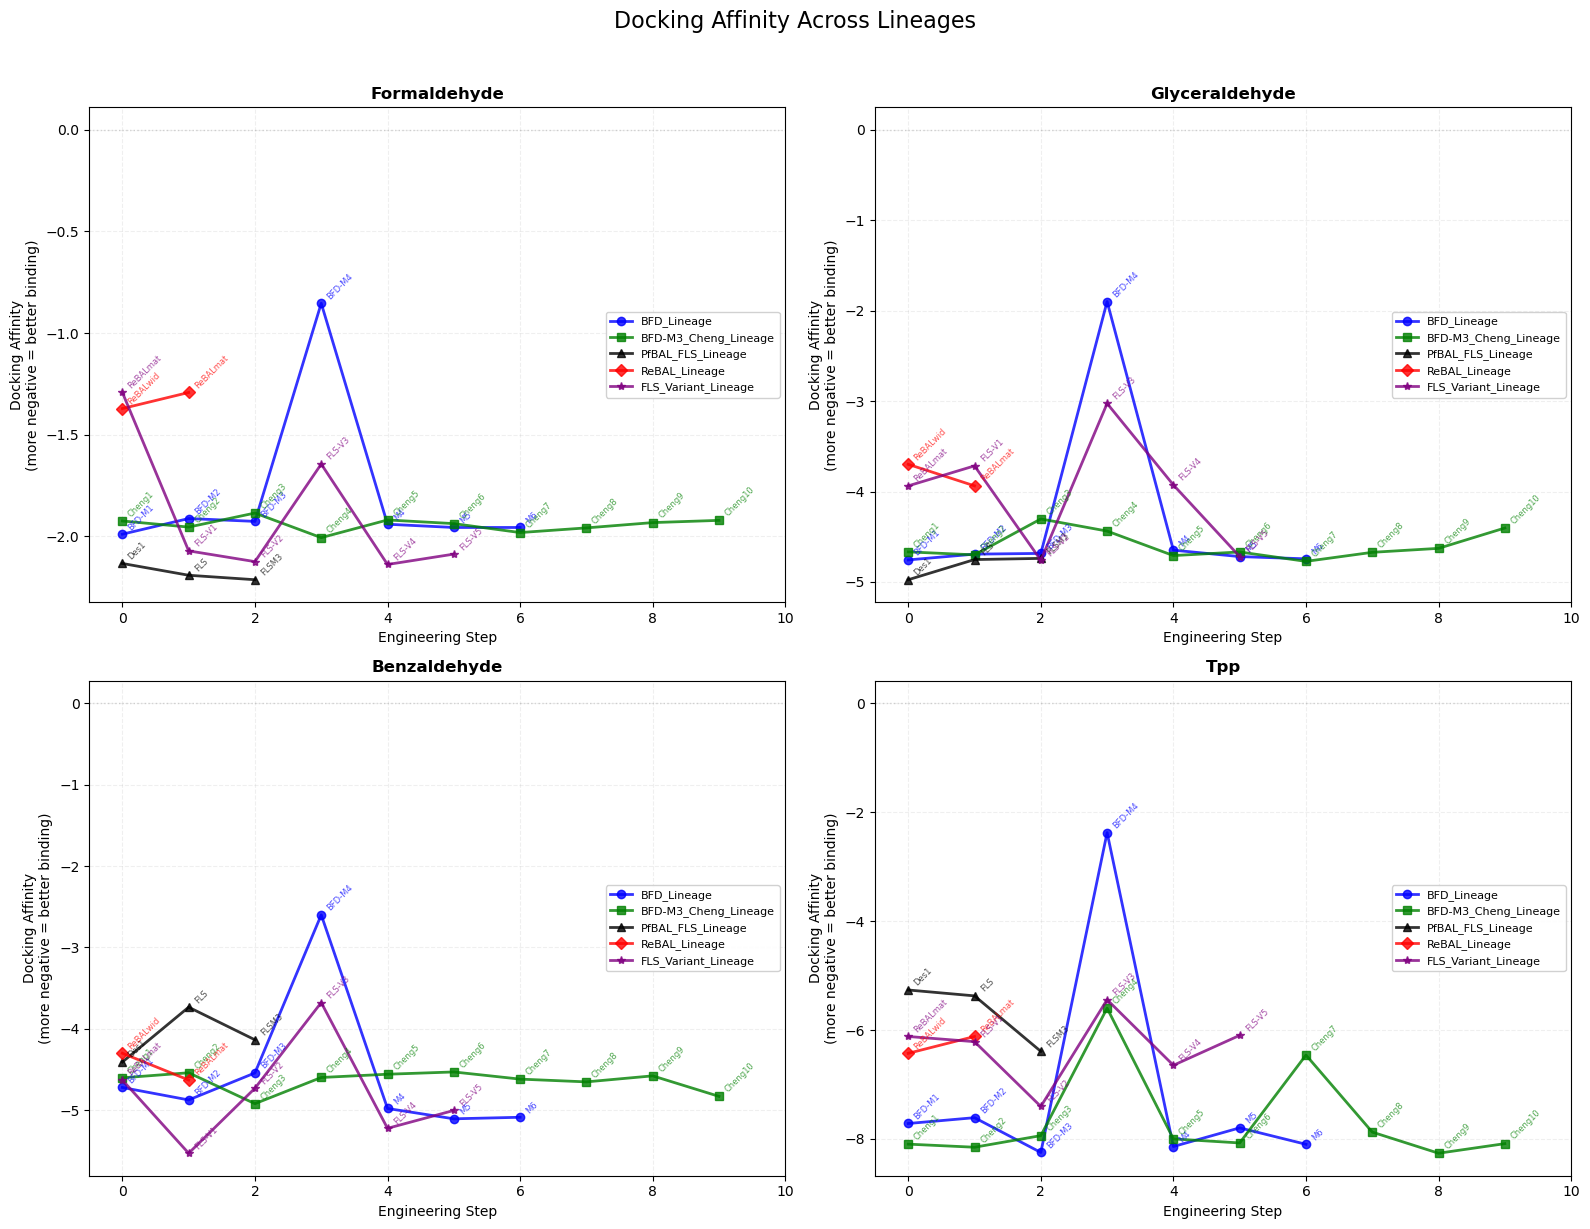

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# READ DATA FROM CSV
# -----------------------------
CSV_FILE = "correct_variant_performance.csv"

# Read the CSV file
df = pd.read_csv(CSV_FILE)

# Define the ligands to plot
ligands = ['formaldehyde', 'glyceraldehyde', 'benzaldehyde', 'TPP']
score_columns = [f"{ligand}_score" for ligand in ligands]

# Define all evolutionary lineages
evolutionary_paths = {
    'BFD_Lineage': [
        'BFD-M1',           # W86R+N87T (ancestor)
        'BFD-M2',        # +L109G+L110E
        'BFD-M3',        # +A460M
        'BFD-M4',        # +H281V+Q282F
        'M4',
        'M5',            # V281Y+F282Q (mutation at position 281 and 282)
        'M6'                 # G109S
    ],
    'BFD-M3_Cheng_Lineage': [
        'Cheng1',        # S26F (branch from BFD-M3)
        'Cheng2',        # G109I
        'Cheng3',        # S236L
        'Cheng4',        # S236F
        'Cheng5',        # H281Y
        'Cheng6',        # C398A
        'Cheng7',        # C398M
        'Cheng8',        # G401L
        'Cheng9',        # G401H
        'Cheng10'        # G401Y
    ],
    'PfBAL_FLS_Lineage': [
        'Des1',           # A28I+A394G+G419N+A480W (ancestor)
        'FLS',             # +W89R+L90T+R188H
        'FLSM3'             # I28L+T90L+N283H (note: I28L instead of A28I)
    ],
    'ReBAL_Lineage': [
        'ReBALwid',       # Q112A+E394A+S416G+T479A (ancestor)
        'ReBALmat'        # Q112L+E394Y+S416G+T479F
    ],
    'FLS_Variant_Lineage': [
        'ReBALmat',       # Starting point (branches from ReBALmat)
        'FLS-V1',      # A28L+A391G+G416N+A475W
        'FLS-V2',      # +Y89R
        'FLS-V3',      # +M90L
        'FLS-V4',      # +P279H
        'FLS-V5'       # +Y89R+M90L+P279H (combination)
    ]
}

# Colors for each lineage
lineage_colors = {
    'BFD_Lineage': 'blue',
    'BFD-M3_Cheng_Lineage': 'green',
    'PfBAL_FLS_Lineage': 'black',
    'ReBAL_Lineage': 'red',
    'FLS_Variant_Lineage': 'purple'
}

# Markers for each lineage
lineage_markers = {
    'BFD_Lineage': 'o',
    'BFD-M3_Cheng_Lineage': 's',
    'PfBAL_FLS_Lineage': '^',
    'ReBAL_Lineage': 'D',
    'FLS_Variant_Lineage': '*'
}

# Create the 2x2 subplot grid (4 plots)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()  # Flatten to easily index

# Store data for summary statistics
summary_data = {}

# Plot each ligand
for idx, (ligand, score_col) in enumerate(zip(ligands, score_columns)):
    ax = axes[idx]
    
    print(f"\nProcessing {ligand}...")
    print("-" * 50)
    
    # Track data for this ligand
    ligand_summary = {}
    
    # Plot each lineage
    for lineage_name, variants in evolutionary_paths.items():
        # Filter variants that exist in the dataframe
        available_variants = [v for v in variants if v in df['enzyme'].values]
        
        if not available_variants:
            print(f"  No variants found for {lineage_name}")
            continue
        
        # Get data for this lineage
        lineage_df = df[df['enzyme'].isin(available_variants)].copy()
        
        # Map variants to their evolutionary steps
        # Only map variants that are in the original lineage order
        valid_steps = {}
        for i, variant in enumerate(variants):
            if variant in available_variants:
                valid_steps[variant] = i
        
        lineage_df['step'] = lineage_df['enzyme'].map(valid_steps)
        lineage_df = lineage_df.sort_values('step')
        
        # Check if we have valid score data
        if lineage_df[score_col].notna().any():
            # Plot the lineage
            ax.plot(lineage_df['step'], lineage_df[score_col], 
                    marker=lineage_markers[lineage_name], 
                    linewidth=2, 
                    markersize=6, 
                    color=lineage_colors[lineage_name],
                    label=lineage_name,
                    linestyle='-',
                    alpha=0.8)
            
            # Add labels for each point (only if not too crowded)
            if len(lineage_df) <= 15:  # Only label if reasonable number of points
                for _, row in lineage_df.iterrows():
                    if pd.notna(row[score_col]):
                        ax.annotate(row['enzyme'], 
                                   xy=(row['step'], row[score_col]),
                                   xytext=(3, 3), 
                                   textcoords='offset points',
                                   fontsize=6, 
                                   color=lineage_colors[lineage_name],
                                   alpha=0.7,
                                   rotation=45)
            
            # Store summary data
            ligand_summary[lineage_name] = {
                'variants': lineage_df['enzyme'].tolist(),
                'scores': lineage_df[score_col].tolist(),
                'min': lineage_df[score_col].min(),
                'max': lineage_df[score_col].max(),
                'mean': lineage_df[score_col].mean(),
                'final': lineage_df[score_col].iloc[-1] if len(lineage_df) > 0 else None,
                'initial': lineage_df[score_col].iloc[0] if len(lineage_df) > 0 else None
            }
            
            # Calculate improvement
            if len(lineage_df) >= 2 and ligand_summary[lineage_name]['initial'] is not None:
                improvement = ligand_summary[lineage_name]['final'] - ligand_summary[lineage_name]['initial']
                ligand_summary[lineage_name]['improvement'] = improvement
                
                arrow = "✓ Improved" if improvement < 0 else "✗ Worsened"
                print(f"  {lineage_name}: {improvement:+.3f} ({arrow})")
            else:
                print(f"  {lineage_name}: Complete")
    
    # Store ligand summary
    summary_data[ligand] = ligand_summary
    
    # Customize each subplot
    ax.set_xlabel("Engineering Step", fontsize=10)
    ax.set_ylabel("Docking Affinity\n(more negative = better binding)", fontsize=10)
    ax.set_title(f"{ligand.capitalize()}", fontsize=12, fontweight='bold')
    
    # Set x-axis ticks
    max_steps = max([len(variants) for variants in evolutionary_paths.values()])
    ax.set_xlim(-0.5, max_steps)
    
    # Add horizontal line at 0 for reference
    ax.axhline(y=0, color='gray', linestyle=':', alpha=0.3, linewidth=1)
    
    # Add legend (only show lineages that actually have data)
    if ax.lines:
        ax.legend(loc='best', fontsize=8, framealpha=0.9)
    
    ax.grid(True, alpha=0.2, linestyle='--')

plt.suptitle("Docking Affinity Across Lineages", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


In [11]:
# Convert data to csv
summary_data
df

,variant_name,mutation_set,replicate,score,starttime,endtime,pdb_file,pdbqt_path,enzyme,residue,center_x,center_y,center_z,formaldehyde_score,glyceraldehyde_score,benzaldehyde_score,TPP_score
0,BFD-M3_Cheng3,S236L,26,-1698.5854,2026-05-11T19:37:28.490976,2026-05-11T20:17:01.240964,output/pdbfiles_mutatescript/BFD-M3_Cheng3/920...,output/bestVariant_pdbs/Cheng/Ch-pdbqt-files/C...,Cheng3,461,27.940,-18.866,10.405,-1.8850,-4.303,-4.921,-7.940
1,ReBALmat-FLS-V2,A28L+Y89R+A391G+G416N+A475W,30,-1786.5513,2026-05-11T18:05:11.200208,2026-05-11T18:57:17.135915,output/lab_variants_PDB_structures/ReBALmat-FL...,output/bestVariant_pdbs/FLS-V/FLS-V2/FLS-V2.pdbqt,FLS-V2,416,11.432,19.979,9.315,-2.1240,-4.760,-4.731,-7.404
2,BFD-BFD-M1,W86R+N87T,24,-1684.8003,2026-05-11T12:25:24.097049,2026-05-11T13:02:22.137164,output/mutated_PDB_structures/BFD-BFD-M1/aaadc...,output/bestVariant_pdbs/BFD/BFD-M1/BFD-M1.pdbqt,BFD-M1,460,10.959,-25.890,3.742,-1.9890,-4.756,-4.722,-7.717
3,BFD-M3_Cheng2,G109I,10,-1694.6637,2026-05-11T19:01:55.741857,2026-05-11T19:39:01.707057,output/pdbfiles_mutatescript/BFD-M3_Cheng2/483...,output/bestVariant_pdbs/Cheng/Ch-pdbqt-files/C...,Cheng2,461,24.182,-25.302,5.578,-1.9540,-4.700,-4.541,-8.153
4,BFD-M3_Cheng8,G401L,6,-1693.9430,2026-05-11T21:18:42.081215,2026-05-11T22:02:10.909815,output/pdbfiles_mutatescript/BFD-M3_Cheng8/806...,output/bestVariant_pdbs/Cheng/Ch-pdbqt-files/C...,Cheng8,461,24.582,-25.501,4.802,-1.9580,-4.672,-4.653,-7.875
5,ReBAL-ReBALwid,Q112A+E394A+S416G+T479A,19,-1789.3884,2026-05-10T14:58:27.304954,2026-05-10T16:00:01.721172,output/mutated_PDB_structures/ReBAL-ReBALwid/a...,input/receptor/ReBAL_mutants/ReBALwid/ReBALwid...,ReBALwid,416,-1.398,-8.857,6.639,-1.3710,-3.699,-4.301,-6.428
6,BFD-M4_M4,V281Y+F282Q,24,-1695.1520,2026-05-11T16:35:31.248490,2026-05-11T17:10:43.238048,output/pdbfiles_mutatescript/BFD-M4_M4/045fbc9...,output/bestVariant_pdbs/BFD/M4/M4.pdbqt,M4,460,21.056,-22.587,7.373,-1.9400,-4.648,-4.980,-8.140
7,PfBAL-Des1,A28I+A394G+G419N+A480W,30,-1745.0302,2026-05-11T13:31:42.600322,2026-05-11T14:18:29.335182,output/pdbfiles_mutatescript/PfBAL-Des1/e73314...,output/bestVariant_pdbs/FLS/Des1.pdbqt,Des1,480,-13.219,4.152,8.050,-2.1330,-4.975,-4.409,-5.265
8,BFD-M3_Cheng1,S26F,23,-1694.4766,2026-05-11T18:52:22.214406,2026-05-11T19:32:25.514781,output/pdbfiles_mutatescript/BFD-M3_Cheng1/976...,output/bestVariant_pdbs/Cheng/Ch-pdbqt-files/C...,Cheng1,461,24.995,-25.002,5.816,-1.9240,-4.667,-4.603,-8.096
9,BFD-M3_Cheng6,C398A,24,-1694.2515,2026-05-11T20:30:20.712431,2026-05-11T21:10:23.444988,output/pdbfiles_mutatescript/BFD-M3_Cheng6/1d3...,output/bestVariant_pdbs/Cheng/Ch-pdbqt-files/C...,Cheng6,461,28.530,-19.396,9.934,-1.9370,-4.668,-4.531,-8.074



COMPREHENSIVE SUMMARY STATISTICS

FORMALDEHYDE

BFD_Lineage:
  Variants: 7
  Score Range: -1.989 to -0.853
  Mean Score: -1.790
  Overall Change: +0.033 ↑ Worsened
  Progression:
    BFD-M1: -1.989
    BFD-M2: -1.912
    BFD-M3: -1.926
    BFD-M4: -0.853
    M4: -1.940
    M5: -1.956
    M6: -1.956

BFD-M3_Cheng_Lineage:
  Variants: 10
  Score Range: -2.006 to -1.885
  Mean Score: -1.942
  Overall Change: +0.003 ↑ Worsened
  Progression:
    Cheng1: -1.924
    Cheng2: -1.954
    Cheng3: -1.885
    Cheng4: -2.006
    Cheng5: -1.919
    Cheng6: -1.937
    Cheng7: -1.981
    Cheng8: -1.958
    Cheng9: -1.932
    Cheng10: -1.921

PfBAL_FLS_Lineage:
  Variants: 3
  Score Range: -2.213 to -2.133
  Mean Score: -2.179
  Overall Change: -0.080 ↓ Improved
  Progression:
    Des1: -2.133
    FLS: -2.191
    FLSM3: -2.213

ReBAL_Lineage:
  Variants: 2
  Score Range: -1.371 to -1.292
  Mean Score: -1.332
  Overall Change: +0.079 ↑ Worsened
  Progression:
    ReBALwid: -1.371
    ReBALmat: -1.292



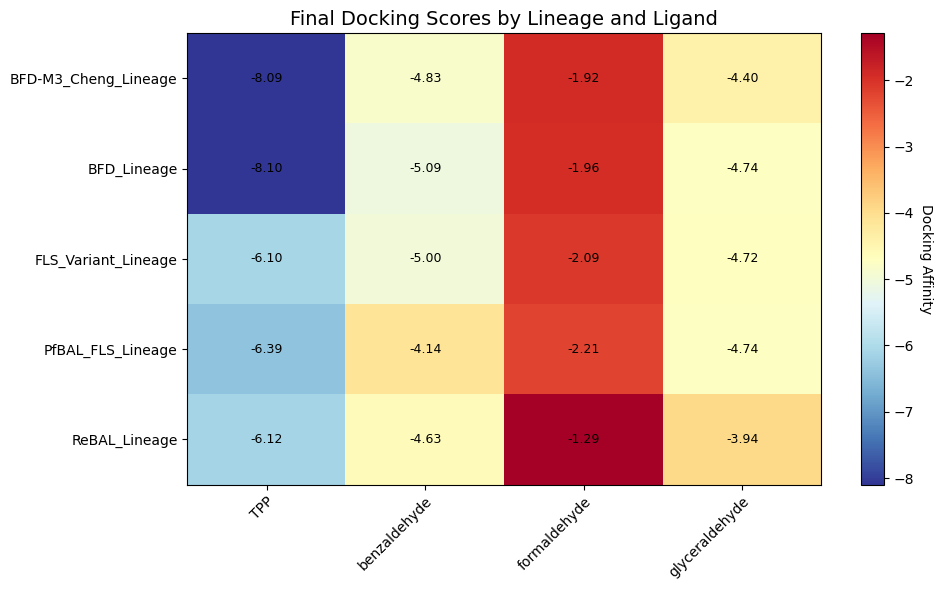


Analysis complete!


In [7]:

# -----------------------------
# PRINT COMPREHENSIVE SUMMARY
# -----------------------------
print("\n" + "="*100)
print("COMPREHENSIVE SUMMARY STATISTICS")
print("="*100)

for ligand in ligands:
    print(f"\n{'='*100}")
    print(f"{ligand.upper()}")
    print(f"{'='*100}")
    
    if ligand in summary_data:
        for lineage_name, stats in summary_data[ligand].items():
            print(f"\n{lineage_name}:")
            print(f"  Variants: {len(stats['variants'])}")
            print(f"  Score Range: {stats['min']:.3f} to {stats['max']:.3f}")
            print(f"  Mean Score: {stats['mean']:.3f}")
            
            if 'improvement' in stats:
                arrow = "↓ Improved" if stats['improvement'] < 0 else "↑ Worsened"
                print(f"  Overall Change: {stats['improvement']:+.3f} {arrow}")
            
            print(f"  Progression:")
            for variant, score in zip(stats['variants'], stats['scores']):
                print(f"    {variant}: {score:.3f}")

# -----------------------------
# CREATE HEATMAP FOR COMPARISON
# -----------------------------
print("\n" + "="*100)
print("HEATMAP: Final Scores by Lineage and Ligand")
print("="*100)

# Create a DataFrame for final scores
final_scores_data = []
for ligand in ligands:
    for lineage_name in evolutionary_paths.keys():
        if ligand in summary_data and lineage_name in summary_data[ligand]:
            final_score = summary_data[ligand][lineage_name]['final']
            if final_score is not None:
                final_scores_data.append({
                    'Lineage': lineage_name,
                    'Ligand': ligand,
                    'Final Score': final_score
                })

if final_scores_data:
    heatmap_df = pd.DataFrame(final_scores_data)
    heatmap_pivot = heatmap_df.pivot(index='Lineage', columns='Ligand', values='Final Score')
    
    fig, ax = plt.subplots(figsize=(10, 6))
    im = ax.imshow(heatmap_pivot.values, cmap='RdYlBu_r', aspect='auto')
    
    # Show all ticks
    ax.set_xticks(np.arange(len(heatmap_pivot.columns)))
    ax.set_yticks(np.arange(len(heatmap_pivot.index)))
    ax.set_xticklabels(heatmap_pivot.columns)
    ax.set_yticklabels(heatmap_pivot.index)
    
    # Rotate x-tick labels
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    
    # Add colorbar
    cbar = ax.figure.colorbar(im, ax=ax)
    cbar.ax.set_ylabel("Docking Affinity", rotation=-90, va="bottom")
    
    # Add text annotations
    for i in range(len(heatmap_pivot.index)):
        for j in range(len(heatmap_pivot.columns)):
            text = ax.text(j, i, f"{heatmap_pivot.iloc[i, j]:.2f}",
                          ha="center", va="center", color="black", fontsize=9)
    
    ax.set_title("Final Docking Scores by Lineage and Ligand", fontsize=14)
    fig.tight_layout()
    plt.show()

print("\nAnalysis complete!")

Boxplots

/tmp/ipykernel_1917521/1836759670.py:55: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  boxplot = ax.boxplot(



BOXPLOT SUMMARY STATISTICS

Formaldehyde:
  Count (n): 30
  Mean: -1.842
  Median: -1.938
  Std Dev: 0.327
  Min: -2.213
  Max: -0.853
  IQR: 0.110

Glyceraldehyde:
  Count (n): 30
  Mean: -4.356
  Median: -4.668
  Std Dev: 0.637
  Min: -4.975
  Max: -1.899
  IQR: 0.601

Benzaldehyde:
  Count (n): 30
  Mean: -4.577
  Median: -4.619
  Std Dev: 0.536
  Min: -5.530
  Max: -2.600
  IQR: 0.330

TPP:
  Count (n): 30
  Mean: -6.872
  Median: -7.026
  Std Dev: 1.339
  Min: -8.263
  Max: -2.375
  IQR: 1.923


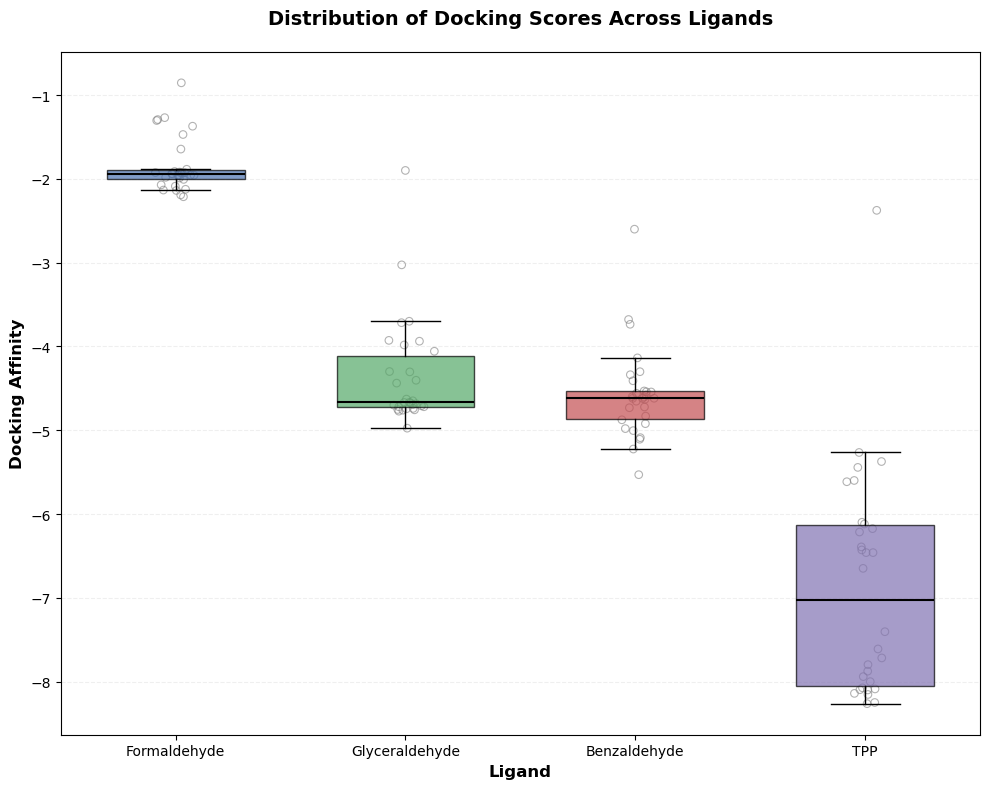

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# READ DATA FROM CSV
# -----------------------------
CSV_FILE = "/home/myrsini/FLS-analysis/correct_variant_performance.csv"

# Read the CSV file
df = pd.read_csv(CSV_FILE)

# Define ligands and their display names
ligand_columns = {
    'formaldehyde_score': 'Formaldehyde',
    'glyceraldehyde_score': 'Glyceraldehyde',
    'benzaldehyde_score': 'Benzaldehyde',
    'TPP_score': 'TPP'
}

# -----------------------------
# PREPARE DATA FOR BOXPLOT
# -----------------------------
# Create a long-format dataframe for seaborn
data_for_plot = []

for score_col, ligand_name in ligand_columns.items():
    # Extract scores for this ligand, drop NaN if any
    scores = df[score_col].dropna()
    
    # Create entries for each score
    for score in scores:
        data_for_plot.append({
            'Ligand': ligand_name,
            'Affinity': score
        })

plot_df = pd.DataFrame(data_for_plot)

# -----------------------------
# CREATE BOXPLOT
# -----------------------------
# Set up the figure
fig, ax = plt.subplots(figsize=(10, 8))

# Define colors for each ligand (subdued, professional palette)
ligand_colors = {
    'Formaldehyde': '#4C72B0',      # muted blue
    'Glyceraldehyde': '#55A868',    # muted green
    'Benzaldehyde': '#C44E52',      # muted red
    'TPP': '#8172B2'                # muted purple
}

# Create boxplot first (so points appear on top)
boxplot = ax.boxplot(
    [plot_df[plot_df['Ligand'] == ligand]['Affinity'] for ligand in ligand_columns.values()],
    labels=ligand_columns.values(),
    patch_artist=True,  # To fill boxes with color
    widths=0.6,
    showmeans=False,
    showfliers=False,
    meanline=False,
    medianprops={'linewidth': 1.5, 'color': 'black'},
    whiskerprops={'linewidth': 1},
    capprops={'linewidth': 1},
    #flierprops={'marker': 'o', 'markersize': 4, 'markerfacecolor': 'gray', 'alpha': 0.5}
)

# Color the boxes
for i, (ligand, color) in enumerate(ligand_colors.items()):
    boxplot['boxes'][i].set_facecolor(color)
    boxplot['boxes'][i].set_alpha(0.7)
    boxplot['boxes'][i].set_edgecolor('black')
    boxplot['boxes'][i].set_linewidth(1)

# Add individual points (gray, open circles)
for i, ligand in enumerate(ligand_columns.values()):
    # Get scores for this ligand
    scores = plot_df[plot_df['Ligand'] == ligand]['Affinity']
    
    # Add jitter to x-coordinates to avoid overlapping points
    x_jitter = np.random.normal(i + 1, 0.04, size=len(scores))
    
    # Plot individual points
    ax.scatter(x_jitter, scores, 
               facecolors='none',  # Non-filled circles
               edgecolors='gray', 
               alpha=0.6, 
               s=30, 
               linewidths=0.8)

# -----------------------------
# CUSTOMIZE PLOT
# -----------------------------
ax.set_xlabel("Ligand", fontsize=12, fontweight='bold')
ax.set_ylabel("Docking Affinity", fontsize=12, fontweight='bold')
ax.set_title("Distribution of Docking Scores Across Ligands", fontsize=14, fontweight='bold', pad=20)

# Add horizontal line at 0 for reference
ax.axhline(y=0, color='gray', linestyle=':', alpha=0.5, linewidth=1)

# Add grid for better readability
ax.grid(True, alpha=0.2, linestyle='--', axis='y')

# Adjust y-axis to give some padding
y_min = plot_df['Affinity'].min()
y_max = plot_df['Affinity'].max()
y_range = y_max - y_min
ax.set_ylim(y_min - y_range*0.05, y_max + y_range*0.05)

# -----------------------------
# PRINT SUMMARY STATISTICS
# -----------------------------
print("\n" + "="*60)
print("BOXPLOT SUMMARY STATISTICS")
print("="*60)

for ligand in ligand_columns.values():
    scores = plot_df[plot_df['Ligand'] == ligand]['Affinity']
    print(f"\n{ligand}:")
    print(f"  Count (n): {len(scores)}")
    print(f"  Mean: {scores.mean():.3f}")
    print(f"  Median: {scores.median():.3f}")
    print(f"  Std Dev: {scores.std():.3f}")
    print(f"  Min: {scores.min():.3f}")
    print(f"  Max: {scores.max():.3f}")
    print(f"  IQR: {scores.quantile(0.75) - scores.quantile(0.25):.3f}")

# Display the plot
plt.tight_layout()
plt.show()

3rd ref15 figure attempt this time using enzyme and step

Loaded 30 unique variants
Plotting Cheng1 at x=3.60, y=-1694.48
Plotting Cheng2 at x=3.69, y=-1694.66
Plotting Cheng3 at x=3.78, y=-1698.59
Plotting Cheng4 at x=3.87, y=-1703.41
Plotting Cheng5 at x=3.96, y=-1694.66
Plotting Cheng6 at x=4.04, y=-1694.25
Plotting Cheng7 at x=4.13, y=-1689.52
Plotting Cheng8 at x=4.22, y=-1693.94
Plotting Cheng9 at x=4.31, y=-1692.31
Plotting Cheng10 at x=4.40, y=-1695.55
Plotting FLS-V1 at x=1.70, y=-1792.79
Plotting FLS-V2 at x=1.85, y=-1786.55
Plotting FLS-V3 at x=2.00, y=-1788.66
Plotting FLS-V4 at x=2.15, y=-1786.81
Plotting FLS-V5 at x=2.30, y=-1783.43
Plotting ReBALwid at x=0.70, y=-1789.39
Plotting ReBALmat at x=1.30, y=-1796.72


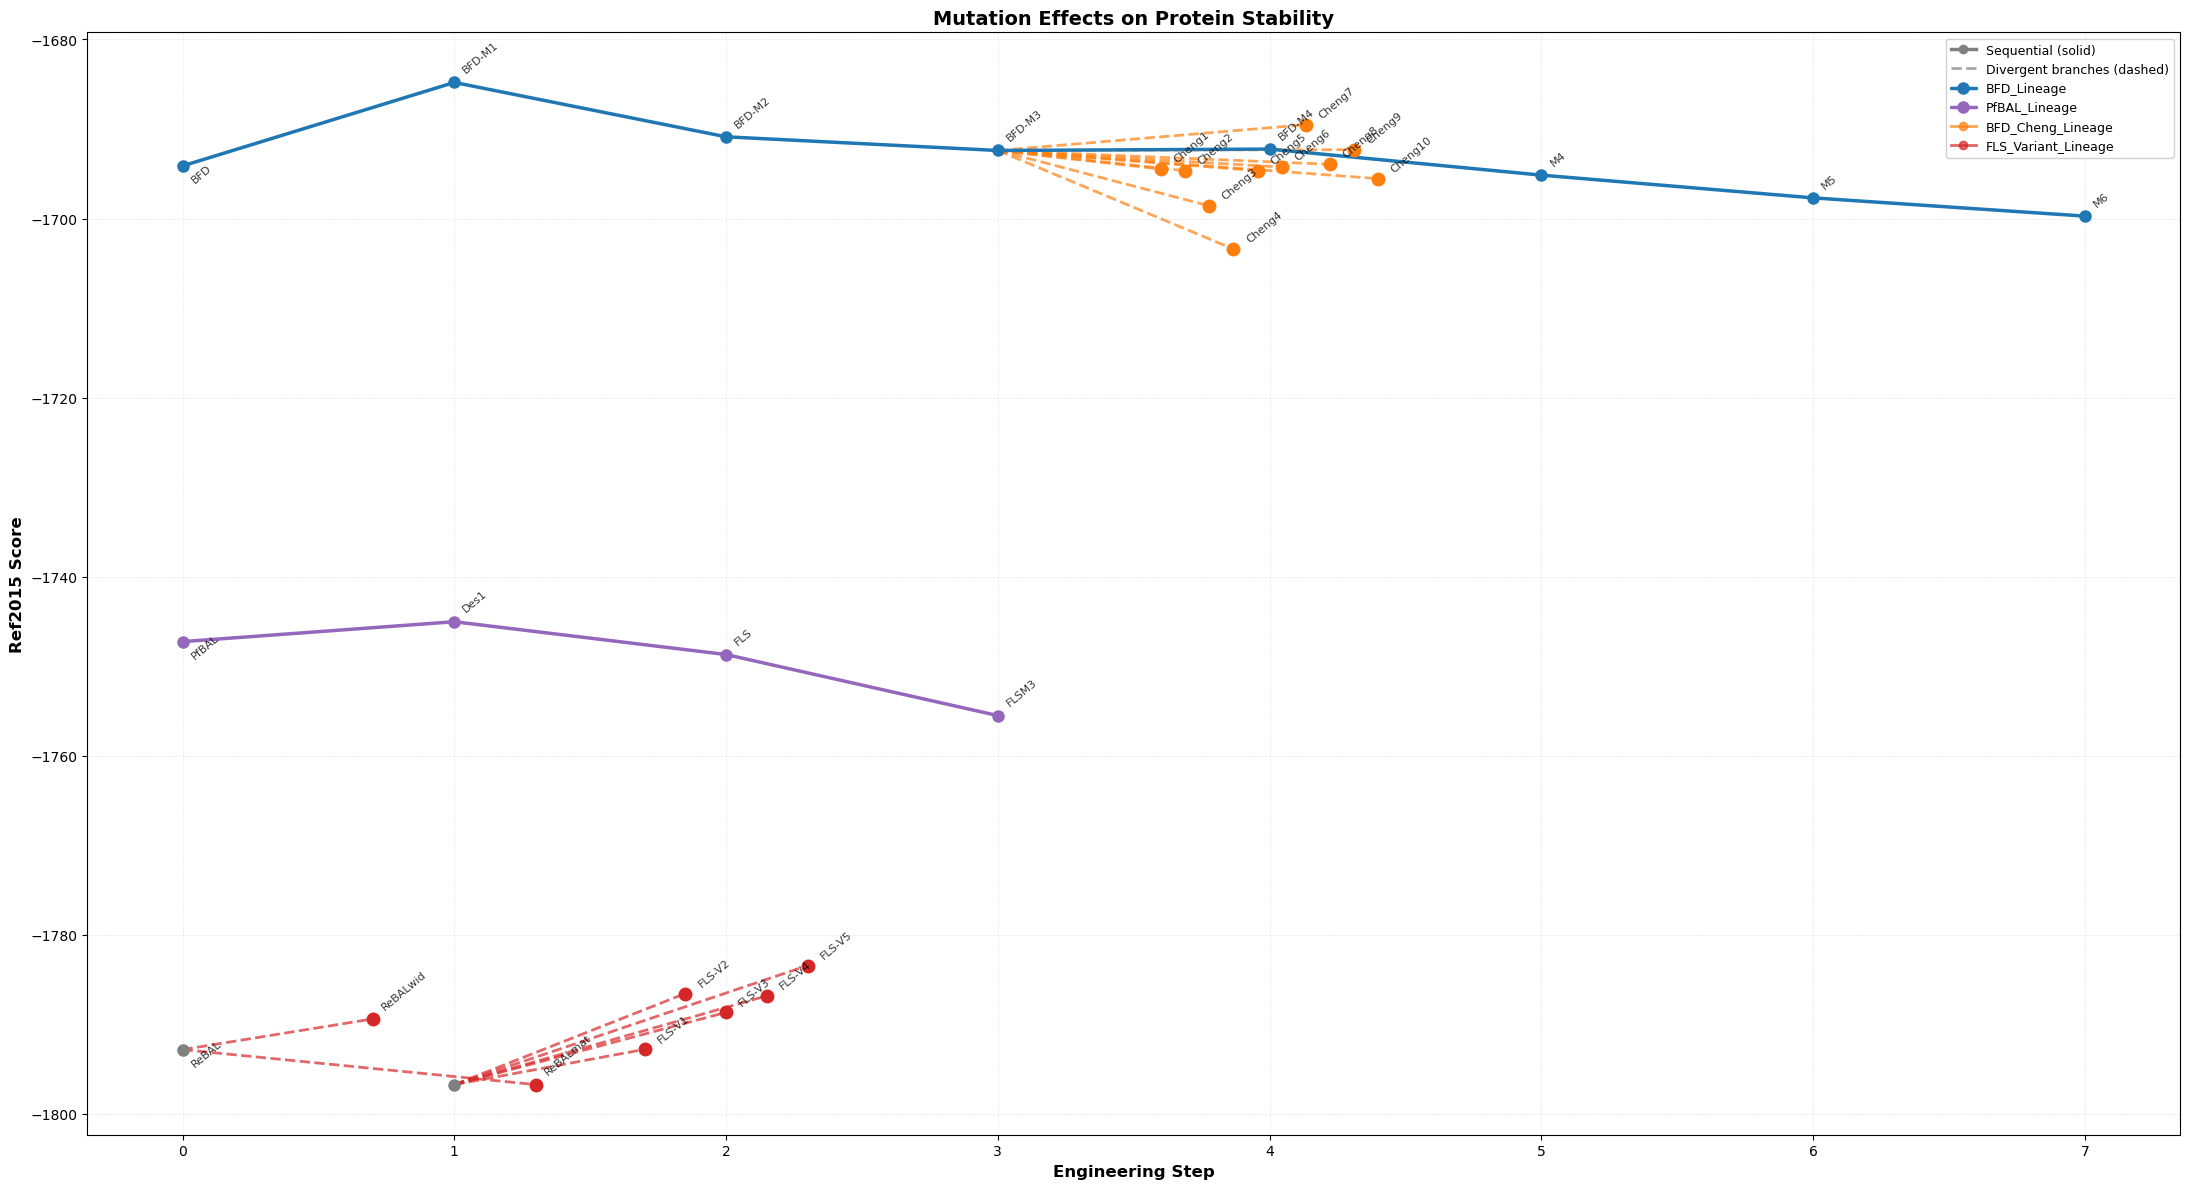


=== Branching Summary ===


From BFD-M3 (step 3, score -1692.40):
  → Cheng1 (step 4): -1694.48 (↓-2.08)
  → Cheng2 (step 4): -1694.66 (↓-2.26)
  → Cheng3 (step 4): -1698.59 (↓-6.19)
  → Cheng4 (step 4): -1703.41 (↓-11.01)
  → Cheng5 (step 4): -1694.66 (↓-2.26)
  → Cheng6 (step 4): -1694.25 (↓-1.85)
  → Cheng7 (step 4): -1689.52 (↑+2.88)
  → Cheng8 (step 4): -1693.94 (↓-1.54)
  → Cheng9 (step 4): -1692.31 (↑+0.09)
  → Cheng10 (step 4): -1695.55 (↓-3.15)

From ReBALmat (step 1, score -1796.72):
  → FLS-V1 (step 2): -1792.79 (↑+3.94)
  → FLS-V2 (step 2): -1786.55 (↑+10.17)
  → FLS-V3 (step 2): -1788.66 (↑+8.07)
  → FLS-V4 (step 2): -1786.81 (↑+9.92)
  → FLS-V5 (step 2): -1783.43 (↑+13.30)

From ReBAL (step 0, score -1792.82):
  → ReBALwid (step 1): -1789.39 (↑+3.43)
  → ReBALmat (step 1): -1796.72 (↓-3.91)


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

csv_path = "/home/myrsini/FLS-analysis/correct_variant_performance.csv" 
df = pd.read_csv(csv_path)

# Use the correct columns
df["score"] = pd.to_numeric(df["score"], errors="coerce")
df = df.dropna(subset=["score"])

# Get unique variants with their steps and scores
variant_data = df[['enzyme', 'step', 'score']].drop_duplicates(subset=['enzyme'])
print(f"Loaded {len(variant_data)} unique variants")

# Define branching relationships
branching_relationships = {
    'BFD-M3': ['Cheng1', 'Cheng2', 'Cheng3', 'Cheng4', 'Cheng5', 
               'Cheng6', 'Cheng7', 'Cheng8', 'Cheng9', 'Cheng10'],
    'ReBALmat': ['FLS-V1', 'FLS-V2', 'FLS-V3', 'FLS-V4', 'FLS-V5'],
    'ReBAL': ['ReBALwid', 'ReBALmat']  # ReBAL is the ancestor of both ReBALwid and ReBALmat
}

# Define sequential paths
sequential_paths = {
    'BFD_Lineage': {
        'color': '#1f77b4',
        'variants': ['BFD', 'BFD-M1', 'BFD-M2', 'BFD-M3', 'BFD-M4', 'M4', 'M5', 'M6']
    },
    'ReBAL_Lineage': {
        'color': '#2ca02c',
        'variants': ['ReBAL']
    },
    'PfBAL_Lineage': {
        'color': '#9467bd',
        'variants': ['PfBAL', 'Des1', 'FLS', 'FLSM3']
    }
}

# Create dictionaries for quick lookup
score_dict = variant_data.set_index('enzyme')['score'].to_dict()
step_dict = variant_data.set_index('enzyme')['step'].to_dict()

# Filter to existing variants
for lineage in sequential_paths:
    existing = [v for v in sequential_paths[lineage]['variants'] if v in score_dict]
    sequential_paths[lineage]['variants'] = existing

for parent in list(branching_relationships.keys()):
    if parent not in score_dict:
        print(f"Warning: Parent {parent} not found")
        continue
    children = [c for c in branching_relationships[parent] if c in score_dict]
    branching_relationships[parent] = children

# Create the plot with more width for jitter
plt.figure(figsize=(22, 12))

# Store all plotted points
all_points = {}

# Keep track of which branch legends we've added
added_branches = set()

# Track vertical offsets for labels at each step to prevent overlap
step_offsets = defaultdict(list)  # step -> list of (variant, y_position)

# Plot sequential paths (solid lines)
for lineage_name, data in sequential_paths.items():
    variants = data['variants']
    if len(variants) < 2:
        continue
    
    steps = []
    scores = []
    for variant in variants:
        if variant in step_dict and variant in score_dict:
            steps.append(step_dict[variant])
            scores.append(score_dict[variant])
            all_points[variant] = (step_dict[variant], score_dict[variant])
    
    plt.plot(steps, scores, 'o-', color=data['color'], 
            linewidth=2.5, markersize=8, label=lineage_name,
            solid_capstyle='round', zorder=2)

# Plot branching relationships
for parent, children in branching_relationships.items():
    if parent not in score_dict or parent not in step_dict:
        continue
    
    parent_step = step_dict[parent]
    parent_score = score_dict[parent]
    
    if parent not in all_points:
        plt.plot(parent_step, parent_score, 'o', color='gray', 
                markersize=8, zorder=2)
        all_points[parent] = (parent_step, parent_score)
    
    # Group children by step
    children_by_step = defaultdict(list)
    for child in children:
        if child in step_dict and child in score_dict:
            children_by_step[step_dict[child]].append(child)
    
    # Determine color for this branch
    if parent == 'BFD-M3':
        branch_color = '#ff7f0e'
        branch_name = 'BFD_Cheng_Lineage'
        jitter_range = 0.4
    else:
        branch_color = '#d62728'
        branch_name = 'FLS_Variant_Lineage'
        jitter_range = 0.3
    
    # Plot each group with jitter
    for step, children_at_step in children_by_step.items():
        num_children = len(children_at_step)
        if num_children == 1:
            offsets = [0]
        else:
            offsets = np.linspace(-jitter_range, jitter_range, num_children)
        
        for child, offset in zip(children_at_step, offsets):
            child_x = step + offset
            child_y = score_dict[child]
            
            print(f"Plotting {child} at x={child_x:.2f}, y={child_y:.2f}")
            
            # Draw dashed line
            plt.plot([parent_step, child_x], [parent_score, child_y], 
                    '--', color=branch_color, linewidth=2, alpha=0.7, zorder=1)
            
            # Plot child point
            plt.plot(child_x, child_y, 'o', color=branch_color, 
                    markersize=9, zorder=3)
            
            all_points[child] = (child_x, child_y)
    
    # Add legend entry for this branch (only once) - FIXED THIS SECTION
    if branch_name not in added_branches:
        plt.plot([], [], 'o-', color=branch_color, linewidth=2, 
                markersize=6, label=branch_name, alpha=0.7)
        added_branches.add(branch_name)

# Add labels for all points - WITHOUT borders
for variant, (x, y) in all_points.items():
    label = variant
    
    # Adjust label position
    if variant in ['BFD', 'ReBAL', 'PfBAL']:
        xytext = (5, -12)
    elif variant.startswith('Cheng'):
        xytext = (8, 5)  # Offset Cheng labels
    elif variant.startswith('FLS-V'):
        xytext = (8, 5)
    else:
        xytext = (5, 7)
    
    plt.annotate(label, xy=(x, y), xytext=xytext, 
                textcoords='offset points', fontsize=8, 
                alpha=0.8, rotation=40, zorder=4,
                bbox=None)

# Customize plot
plt.xlabel("Engineering Step", fontsize=12, fontweight='bold')
plt.ylabel("Ref2015 Score", fontsize=12, fontweight='bold')
plt.title("Mutation Effects on Protein Stability", 
          fontsize=14, fontweight='bold')

# Set x-axis to show all steps clearly
plt.xticks(range(int(min(step_dict.values())), int(max(step_dict.values())) + 1))

# Legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='gray', lw=2.5, linestyle='-', marker='o', markersize=6, label='Sequential (solid)'),
    Line2D([0], [0], color='gray', lw=2, linestyle='--', alpha=0.7, label='Divergent branches (dashed)'),
]

# Get existing legends
handles, labels = plt.gca().get_legend_handles_labels()
for handle, label in zip(handles, labels):
    legend_elements.append((handle, label))

# Remove duplicates
unique_legend = {}
for item in legend_elements:
    if isinstance(item, tuple):
        if item[1] not in unique_legend:
            unique_legend[item[1]] = item[0]
    else:
        if item.get_label() not in unique_legend:
            unique_legend[item.get_label()] = item

plt.legend(handles=unique_legend.values(), labels=unique_legend.keys(), 
          loc='best', fontsize=9, framealpha=0.9)
plt.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

# Print summary
print("\n=== Branching Summary ===\n")
for parent, children in branching_relationships.items():
    if parent in score_dict:
        print(f"\nFrom {parent} (step {step_dict[parent]}, score {score_dict[parent]:.2f}):")
        for child in children:
            if child in score_dict:
                delta = score_dict[child] - score_dict[parent]
                arrow = "↑" if delta > 0 else "↓"
                print(f"  → {child} (step {step_dict[child]}): {score_dict[child]:.2f} ({arrow}{delta:+.2f})")

to show

Step dictionary sample: {'BFD': 0, 'BFD-M1': 1, 'BFD-M2': 2, 'BFD-M3': 3, 'BFD-M4': 4}

Plotting formaldehyde (column: formaldehyde_score)
Found 30 variants with valid formaldehyde scores

  Processing BFD_Lineage: ['BFD', 'BFD-M1', 'BFD-M2', 'BFD-M3', 'BFD-M4', 'M4', 'M5', 'M6']
    Added BFD: step=0, score=-1.269
    Added BFD-M1: step=1, score=-1.989
    Added BFD-M2: step=2, score=-1.912
    Added BFD-M3: step=3, score=-1.926
    Added BFD-M4: step=4, score=-0.853
    Added M4: step=5, score=-1.940
    Added M5: step=6, score=-1.956
    Added M6: step=7, score=-1.956
    Plotting BFD_Lineage with 8 points

  Processing ReBAL_Lineage: ['ReBAL', 'ReBALmat', 'ReBALwid']
    Added ReBAL: step=0, score=-1.303
    Added ReBALmat: step=1, score=-1.292
    Added ReBALwid: step=1, score=-1.371
    Plotting ReBAL_Lineage with 3 points

  Processing PfBAL_Lineage: ['PfBAL', 'Des1', 'FLS', 'FLSM3']
    Added PfBAL: step=0, score=-1.470
    Added Des1: step=1, score=-2.133
    Added FLS: step=2

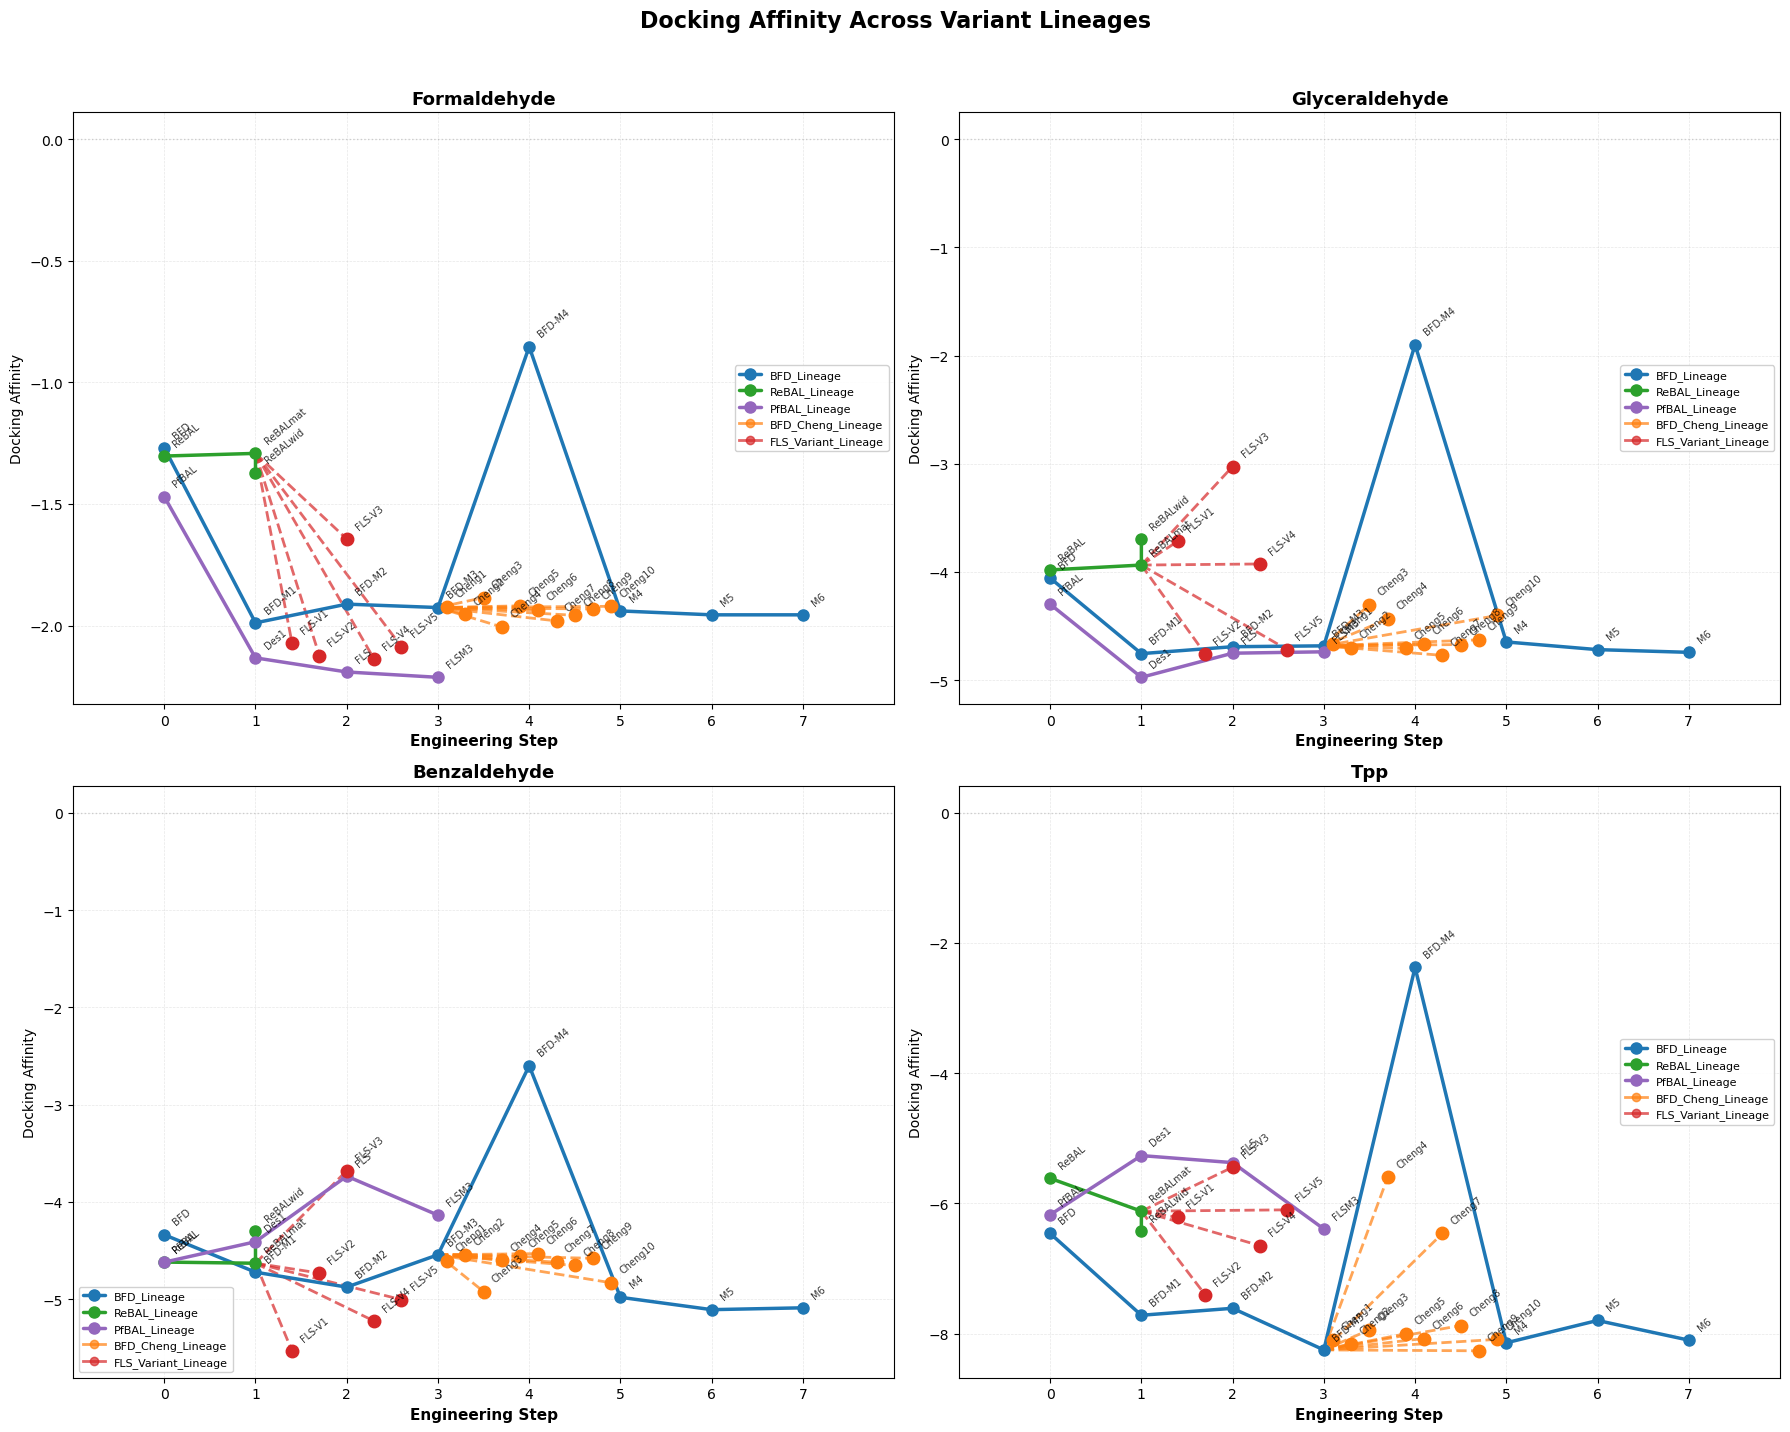


Plot generation complete. Check the printed output above for any issues.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

# -----------------------------
# READ DATA FROM CSV
# -----------------------------
CSV_FILE = "/home/myrsini/FLS-analysis/correct_variant_performance.csv"
df = pd.read_csv(CSV_FILE)

# Define the ligands to plot
ligands = ['formaldehyde', 'glyceraldehyde', 'benzaldehyde', 'TPP']
score_columns = [f"{ligand}_score" for ligand in ligands]

# Convert score columns to numeric
for col in score_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Define sequential paths
sequential_paths = {
    'BFD_Lineage': {
        'color': '#1f77b4',
        'variants': ['BFD', 'BFD-M1', 'BFD-M2', 'BFD-M3', 'BFD-M4', 'M4', 'M5', 'M6']
    },
    'ReBAL_Lineage': {
        'color': '#2ca02c',
        'variants': ['ReBAL', 'ReBALmat', 'ReBALwid']
    },
    'PfBAL_Lineage': {
        'color': '#9467bd',
        'variants': ['PfBAL', 'Des1', 'FLS', 'FLSM3']
    }
}

# Define branching relationships
branching_relationships = {
    'BFD-M3': ['Cheng1', 'Cheng2', 'Cheng3', 'Cheng4', 'Cheng5', 
               'Cheng6', 'Cheng7', 'Cheng8', 'Cheng9', 'Cheng10'],
    'ReBALmat': ['FLS-V1', 'FLS-V2', 'FLS-V3', 'FLS-V4', 'FLS-V5']
}

# Get step numbers from CSV
step_dict = df.set_index('enzyme')['step'].to_dict()
print(f"Step dictionary sample: {dict(list(step_dict.items())[:5])}")

# Create the 2x2 subplot grid
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

# Plot each ligand
for idx, (ligand, score_col) in enumerate(zip(ligands, score_columns)):
    print(f"\n{'='*50}")
    print(f"Plotting {ligand} (column: {score_col})")
    print(f"{'='*50}")
    
    ax = axes[idx]
    
    # Create score dictionary for this ligand
    score_dict = df.set_index('enzyme')[score_col].to_dict()
    
    # Check if we have valid data
    valid_scores = {k: v for k, v in score_dict.items() if pd.notna(v)}
    print(f"Found {len(valid_scores)} variants with valid {ligand} scores")
    
    # Store all plotted points
    all_points = {}
    added_branches = set()
    
    # Plot sequential paths
    for lineage_name, data in sequential_paths.items():
        variants = data['variants']
        print(f"\n  Processing {lineage_name}: {variants}")
        
        # Get available variants
        available = []
        steps = []
        scores = []
        for variant in variants:
            if variant in step_dict and variant in score_dict:
                if pd.notna(score_dict[variant]):
                    available.append(variant)
                    steps.append(step_dict[variant])
                    scores.append(score_dict[variant])
                    print(f"    Added {variant}: step={step_dict[variant]}, score={score_dict[variant]:.3f}")
        
        if len(available) >= 2:
            print(f"    Plotting {lineage_name} with {len(available)} points")
            ax.plot(steps, scores, 'o-', color=data['color'], 
                    linewidth=2.5, markersize=8, label=lineage_name,
                    solid_capstyle='round', zorder=2)
            
            # Store points
            for i, variant in enumerate(available):
                all_points[variant] = (steps[i], scores[i])
        else:
            print(f"    Not enough points for {lineage_name} (only {len(available)})")
    
    # Plot branching relationships
    print(f"\n  Processing branching relationships:")
    for parent, children in branching_relationships.items():
        print(f"    Parent: {parent}")
        
        if parent not in score_dict or pd.isna(score_dict[parent]):
            print(f"      Parent {parent} not found or has NaN score")
            continue
        
        if parent not in step_dict:
            print(f"      Parent {parent} has no step number")
            continue
        
        parent_step = step_dict[parent]
        parent_score = score_dict[parent]
        print(f"      Parent at step {parent_step}, score {parent_score:.3f}")
        
        # Get available children
        available_children = []
        for child in children:
            if child in step_dict and child in score_dict:
                if pd.notna(score_dict[child]):
                    available_children.append(child)
                    print(f"        Child {child}: step={step_dict[child]}, score={score_dict[child]:.3f}")
        
        if not available_children:
            print(f"      No valid children for {parent}")
            continue
        
        # Group children by step
        children_by_step = defaultdict(list)
        for child in available_children:
            children_by_step[step_dict[child]].append(child)
        
        # Determine branch styling
        if parent == 'BFD-M3':
            branch_color = '#ff7f0e'
            branch_name = 'BFD_Cheng_Lineage'
            jitter_range = 0.9
        else:
            branch_color = '#d62728'
            branch_name = 'FLS_Variant_Lineage'
            jitter_range = 0.6
        
        # Plot children
        for step, children_at_step in children_by_step.items():
            print(f"      Plotting {len(children_at_step)} children at step {step}")
            num_children = len(children_at_step)
            
            if num_children == 1:
                offsets = [0]
            else:
                offsets = np.linspace(-jitter_range, jitter_range, num_children)
            
            for child, offset in zip(children_at_step, offsets):
                child_x = step + offset
                child_y = score_dict[child]
                print(f"        {child}: x={child_x:.2f}, y={child_y:.3f}")
                
                # Draw dashed line
                ax.plot([parent_step, child_x], [parent_score, child_y], 
                        '--', color=branch_color, linewidth=2, alpha=0.7, zorder=1)
                
                # Plot child point
                ax.plot(child_x, child_y, 'o', color=branch_color, 
                        markersize=9, zorder=3)
                
                all_points[child] = (child_x, child_y)
        
        # Add legend
        if branch_name not in added_branches:
            ax.plot([], [], 'o-', color=branch_color, linewidth=2, 
                    markersize=6, label=branch_name, alpha=0.7)
            added_branches.add(branch_name)
    
    # Add labels
    print(f"\n  Adding {len(all_points)} point labels")
    for variant, (x, y) in all_points.items():
        ax.annotate(variant, xy=(x, y), xytext=(5, 7), 
                   textcoords='offset points', fontsize=7, 
                   alpha=0.8, rotation=40, zorder=4)
    
    # Customize subplot
    ax.set_xlabel("Engineering Step", fontsize=11, fontweight='bold')
    ax.set_ylabel("Docking Affinity", fontsize=10)
    ax.set_title(f"{ligand.capitalize()}", fontsize=13, fontweight='bold')
    
    # Set x-axis limits based on step values
    all_steps = [step for step in step_dict.values() if pd.notna(step)]
    if all_steps:
        ax.set_xlim(min(all_steps) - 1, max(all_steps) + 1)
        ax.set_xticks(range(int(min(all_steps)), int(max(all_steps)) + 1))
    
    ax.axhline(y=0, color='gray', linestyle=':', alpha=0.3, linewidth=1)
    
    handles, labels = ax.get_legend_handles_labels()
    if handles:
        ax.legend(loc='best', fontsize=8, framealpha=0.9)
    
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)

plt.suptitle("Docking Affinity Across Variant Lineages", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n" + "="*50)
print("Plot generation complete. Check the printed output above for any issues.")

remove jitters keep at same step

Loaded 30 unique variants


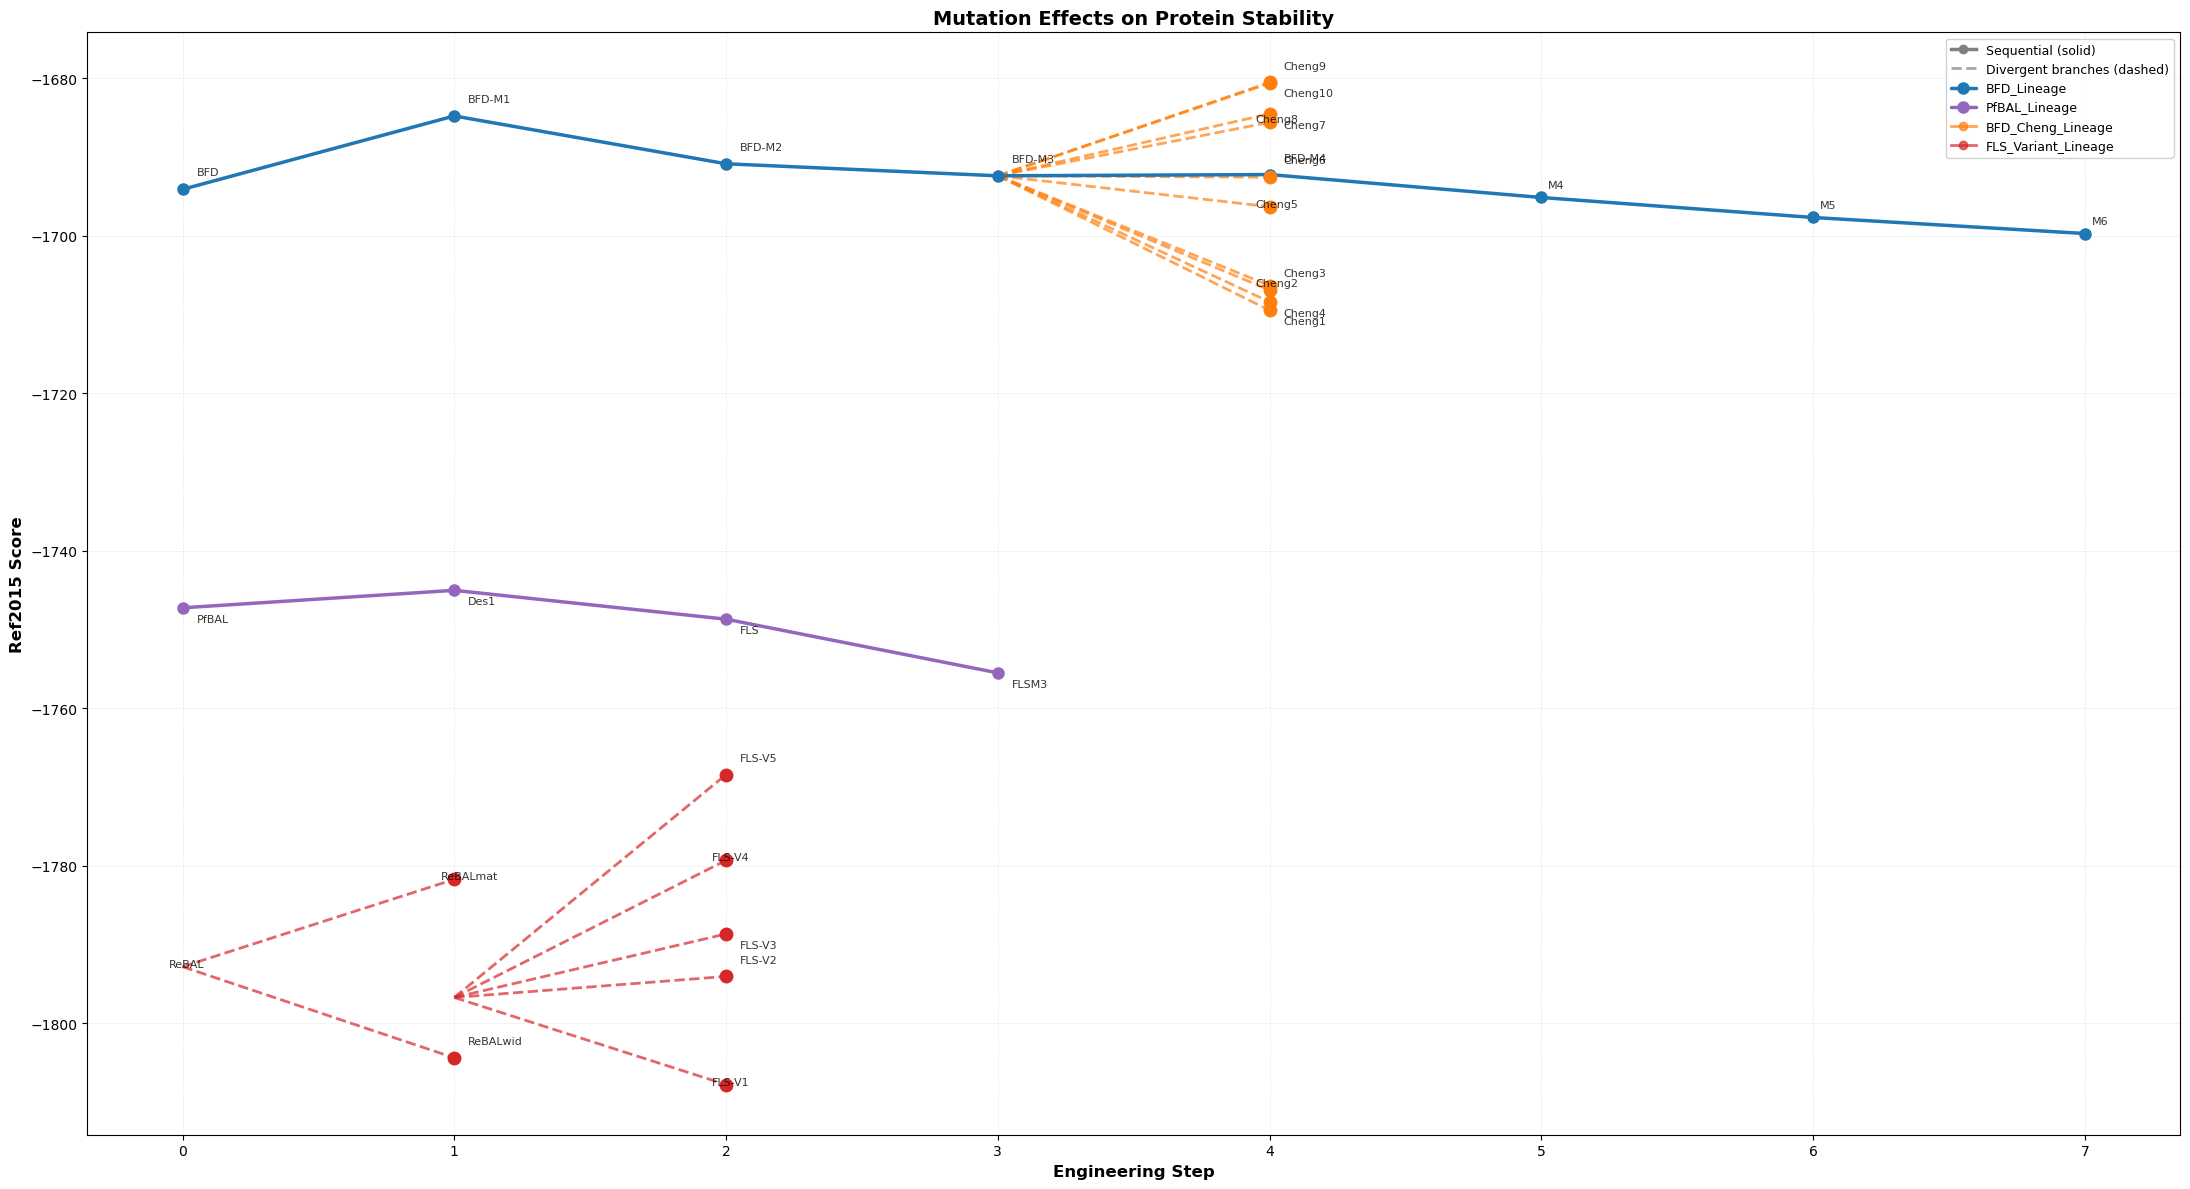


=== Branching Summary ===


From BFD-M3 (step 3, score -1692.40):
  → Cheng1 (step 4): -1694.48 (↓-2.08)
  → Cheng2 (step 4): -1694.66 (↓-2.26)
  → Cheng3 (step 4): -1698.59 (↓-6.19)
  → Cheng4 (step 4): -1703.41 (↓-11.01)
  → Cheng5 (step 4): -1694.66 (↓-2.26)
  → Cheng6 (step 4): -1694.25 (↓-1.85)
  → Cheng7 (step 4): -1689.52 (↑+2.88)
  → Cheng8 (step 4): -1693.94 (↓-1.54)
  → Cheng9 (step 4): -1692.31 (↑+0.09)
  → Cheng10 (step 4): -1695.55 (↓-3.15)

From ReBALmat (step 1, score -1796.72):
  → FLS-V1 (step 2): -1792.79 (↑+3.94)
  → FLS-V2 (step 2): -1786.55 (↑+10.17)
  → FLS-V3 (step 2): -1788.66 (↑+8.07)
  → FLS-V4 (step 2): -1786.81 (↑+9.92)
  → FLS-V5 (step 2): -1783.43 (↑+13.30)

From ReBAL (step 0, score -1792.82):
  → ReBALwid (step 1): -1789.39 (↑+3.43)
  → ReBALmat (step 1): -1796.72 (↓-3.91)


In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

# Load your CSV
csv_path = "/home/myrsini/FLS-analysis/correct_variant_performance.csv" 
df = pd.read_csv(csv_path)

# Use the correct columns
df["score"] = pd.to_numeric(df["score"], errors="coerce")
df = df.dropna(subset=["score"])

# Get unique variants with their steps and scores
variant_data = df[['enzyme', 'step', 'score']].drop_duplicates(subset=['enzyme'])
print(f"Loaded {len(variant_data)} unique variants")

# Define branching relationships
branching_relationships = {
    'BFD-M3': ['Cheng1', 'Cheng2', 'Cheng3', 'Cheng4', 'Cheng5', 
               'Cheng6', 'Cheng7', 'Cheng8', 'Cheng9', 'Cheng10'],
    'ReBALmat': ['FLS-V1', 'FLS-V2', 'FLS-V3', 'FLS-V4', 'FLS-V5'],
    'ReBAL': ['ReBALwid', 'ReBALmat']
}

# Define sequential paths
sequential_paths = {
    'BFD_Lineage': {
        'color': '#1f77b4',
        'variants': ['BFD', 'BFD-M1', 'BFD-M2', 'BFD-M3', 'BFD-M4', 'M4', 'M5', 'M6']
    },
    'ReBAL_Lineage': {
        'color': '#2ca02c',
        'variants': ['ReBAL']
    },
    'PfBAL_Lineage': {
        'color': '#9467bd',
        'variants': ['PfBAL', 'Des1', 'FLS', 'FLSM3']
    }
}

# Create dictionaries for quick lookup
score_dict = variant_data.set_index('enzyme')['score'].to_dict()
step_dict = variant_data.set_index('enzyme')['step'].to_dict()

# Filter to existing variants
for lineage in sequential_paths:
    existing = [v for v in sequential_paths[lineage]['variants'] if v in score_dict]
    sequential_paths[lineage]['variants'] = existing

for parent in list(branching_relationships.keys()):
    if parent not in score_dict:
        print(f"Warning: Parent {parent} not found")
        continue
    children = [c for c in branching_relationships[parent] if c in score_dict]
    branching_relationships[parent] = children

# Create the plot
plt.figure(figsize=(22, 12))

# Store all plotted points with their actual positions
all_points = {}

# Keep track of which branch legends we've added
added_branches = set()

# Track vertical offsets for labels at each step to prevent overlap
step_offsets = defaultdict(list)  # step -> list of (variant, y_position)

# Plot sequential paths (solid lines)
for lineage_name, data in sequential_paths.items():
    variants = data['variants']
    if len(variants) < 2:
        continue
    
    steps = []
    scores = []
    for variant in variants:
        if variant in step_dict and variant in score_dict:
            step = step_dict[variant]
            score = score_dict[variant]
            steps.append(step)
            scores.append(score)
            all_points[variant] = (step, score)
            step_offsets[step].append((variant, score))
    
    plt.plot(steps, scores, 'o-', color=data['color'], 
            linewidth=2.5, markersize=8, label=lineage_name,
            solid_capstyle='round', zorder=2)

# Plot branching relationships
for parent, children in branching_relationships.items():
    if parent not in score_dict or parent not in step_dict:
        continue
    
    parent_step = step_dict[parent]
    parent_score = score_dict[parent]
    
    if parent not in all_points:
        #plt.plot(parent_step, parent_score, 'o', color='gray', 
        #        markersize=8, zorder=2)
        all_points[parent] = (parent_step, parent_score)
        step_offsets[parent_step].append((parent, parent_score))
    
    # Group children by step
    children_by_step = defaultdict(list)
    for child in children:
        if child in step_dict and child in score_dict:
            children_by_step[step_dict[child]].append(child)
    
    # Determine color for this branch
    if parent == 'BFD-M3':
        branch_color = '#ff7f0e'
        branch_name = 'BFD_Cheng_Lineage'
    else:
        branch_color = '#d62728'
        branch_name = 'FLS_Variant_Lineage'
    
    # Plot each group - vertical offsets
    for step, children_at_step in children_by_step.items():
        num_children = len(children_at_step)
        
        # Calculate vertical offsets (spread out in y-direction)
        if num_children == 1:
            y_offsets = [0]
        else:
            # Spread children vertically by ±10-15 points to avoid overlap
            y_spread = 15  # Adjust this value to control vertical separation
            y_offsets = np.linspace(-y_spread, y_spread, num_children)
        
        for child, y_offset in zip(children_at_step, y_offsets):
            child_x = step 
            child_y = score_dict[child] + y_offset  # Apply vertical offset
            
            # Store for label positioning
            all_points[child] = (child_x, child_y)
            step_offsets[step].append((child, child_y))
            
            # Draw dashed line from parent to child
            plt.plot([parent_step, child_x], [parent_score, child_y], 
                    '--', color=branch_color, linewidth=2, alpha=0.7, zorder=1)
            
            # Plot child point at exact step
            plt.plot(child_x, child_y, 'o', color=branch_color, 
                    markersize=9, zorder=3)
    
    # Add legend entry for this branch (only once)
    if branch_name not in added_branches:
        plt.plot([], [], 'o-', color=branch_color, linewidth=2, 
                markersize=6, label=branch_name, alpha=0.7)
        added_branches.add(branch_name)

# Add labels - now with smarter positioning
for variant, (x, y) in all_points.items():
    label = variant
    
    # Calculate vertical offset for variants at the same step
    variants_at_step = [v for v, _ in step_offsets[x]]
    if len(variants_at_step) > 1:
        # Find position in the list to offset label
        pos = variants_at_step.index(variant)
        total = len(variants_at_step)
        # Alternate label positions: some above, some below, some left/right
        if pos % 3 == 0:
            xytext = (10, 10)  # up-right
        elif pos % 3 == 1:
            xytext = (10, -10)  # down-right
        else:
            xytext = (-10, 0)  # left
    else:
        # Default positioning based on variant type
        if variant in ['BFD', 'ReBAL', 'PfBAL']:
            xytext = (5, -12)
        elif variant.startswith('Cheng'):
            xytext = (8, 8)
        elif variant.startswith('FLS-V'):
            xytext = (8, -8)
        else:
            xytext = (5, 7)
    
    plt.annotate(label, xy=(x, y), xytext=xytext, 
                textcoords='offset points', fontsize=8, 
                alpha=0.8, rotation=0, zorder=4,  # Removed rotation for clarity
                bbox=None)

# Customize plot
plt.xlabel("Engineering Step", fontsize=12, fontweight='bold')
plt.ylabel("Ref2015 Score", fontsize=12, fontweight='bold')
plt.title("Mutation Effects on Protein Stability", 
          fontsize=14, fontweight='bold')

# Set x-axis to show all steps clearly
plt.xticks(range(int(min(step_dict.values())), int(max(step_dict.values())) + 1))

# Legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='gray', lw=2.5, linestyle='-', marker='o', markersize=6, label='Sequential (solid)'),
    Line2D([0], [0], color='gray', lw=2, linestyle='--', alpha=0.7, label='Divergent branches (dashed)'),
]

# Get existing legends
handles, labels = plt.gca().get_legend_handles_labels()
for handle, label in zip(handles, labels):
    legend_elements.append((handle, label))

# Remove duplicates
unique_legend = {}
for item in legend_elements:
    if isinstance(item, tuple):
        if item[1] not in unique_legend:
            unique_legend[item[1]] = item[0]
    else:
        if item.get_label() not in unique_legend:
            unique_legend[item.get_label()] = item

plt.legend(handles=unique_legend.values(), labels=unique_legend.keys(), 
          loc='best', fontsize=9, framealpha=0.9)
plt.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

# Print summary
print("\n=== Branching Summary ===\n")
for parent, children in branching_relationships.items():
    if parent in score_dict:
        print(f"\nFrom {parent} (step {step_dict[parent]}, score {score_dict[parent]:.2f}):")
        for child in children:
            if child in score_dict:
                delta = score_dict[child] - score_dict[parent]
                arrow = "↑" if delta > 0 else "↓"
                print(f"  → {child} (step {step_dict[child]}): {score_dict[child]:.2f} ({arrow}{delta:+.2f})")

Loaded 30 unique variants


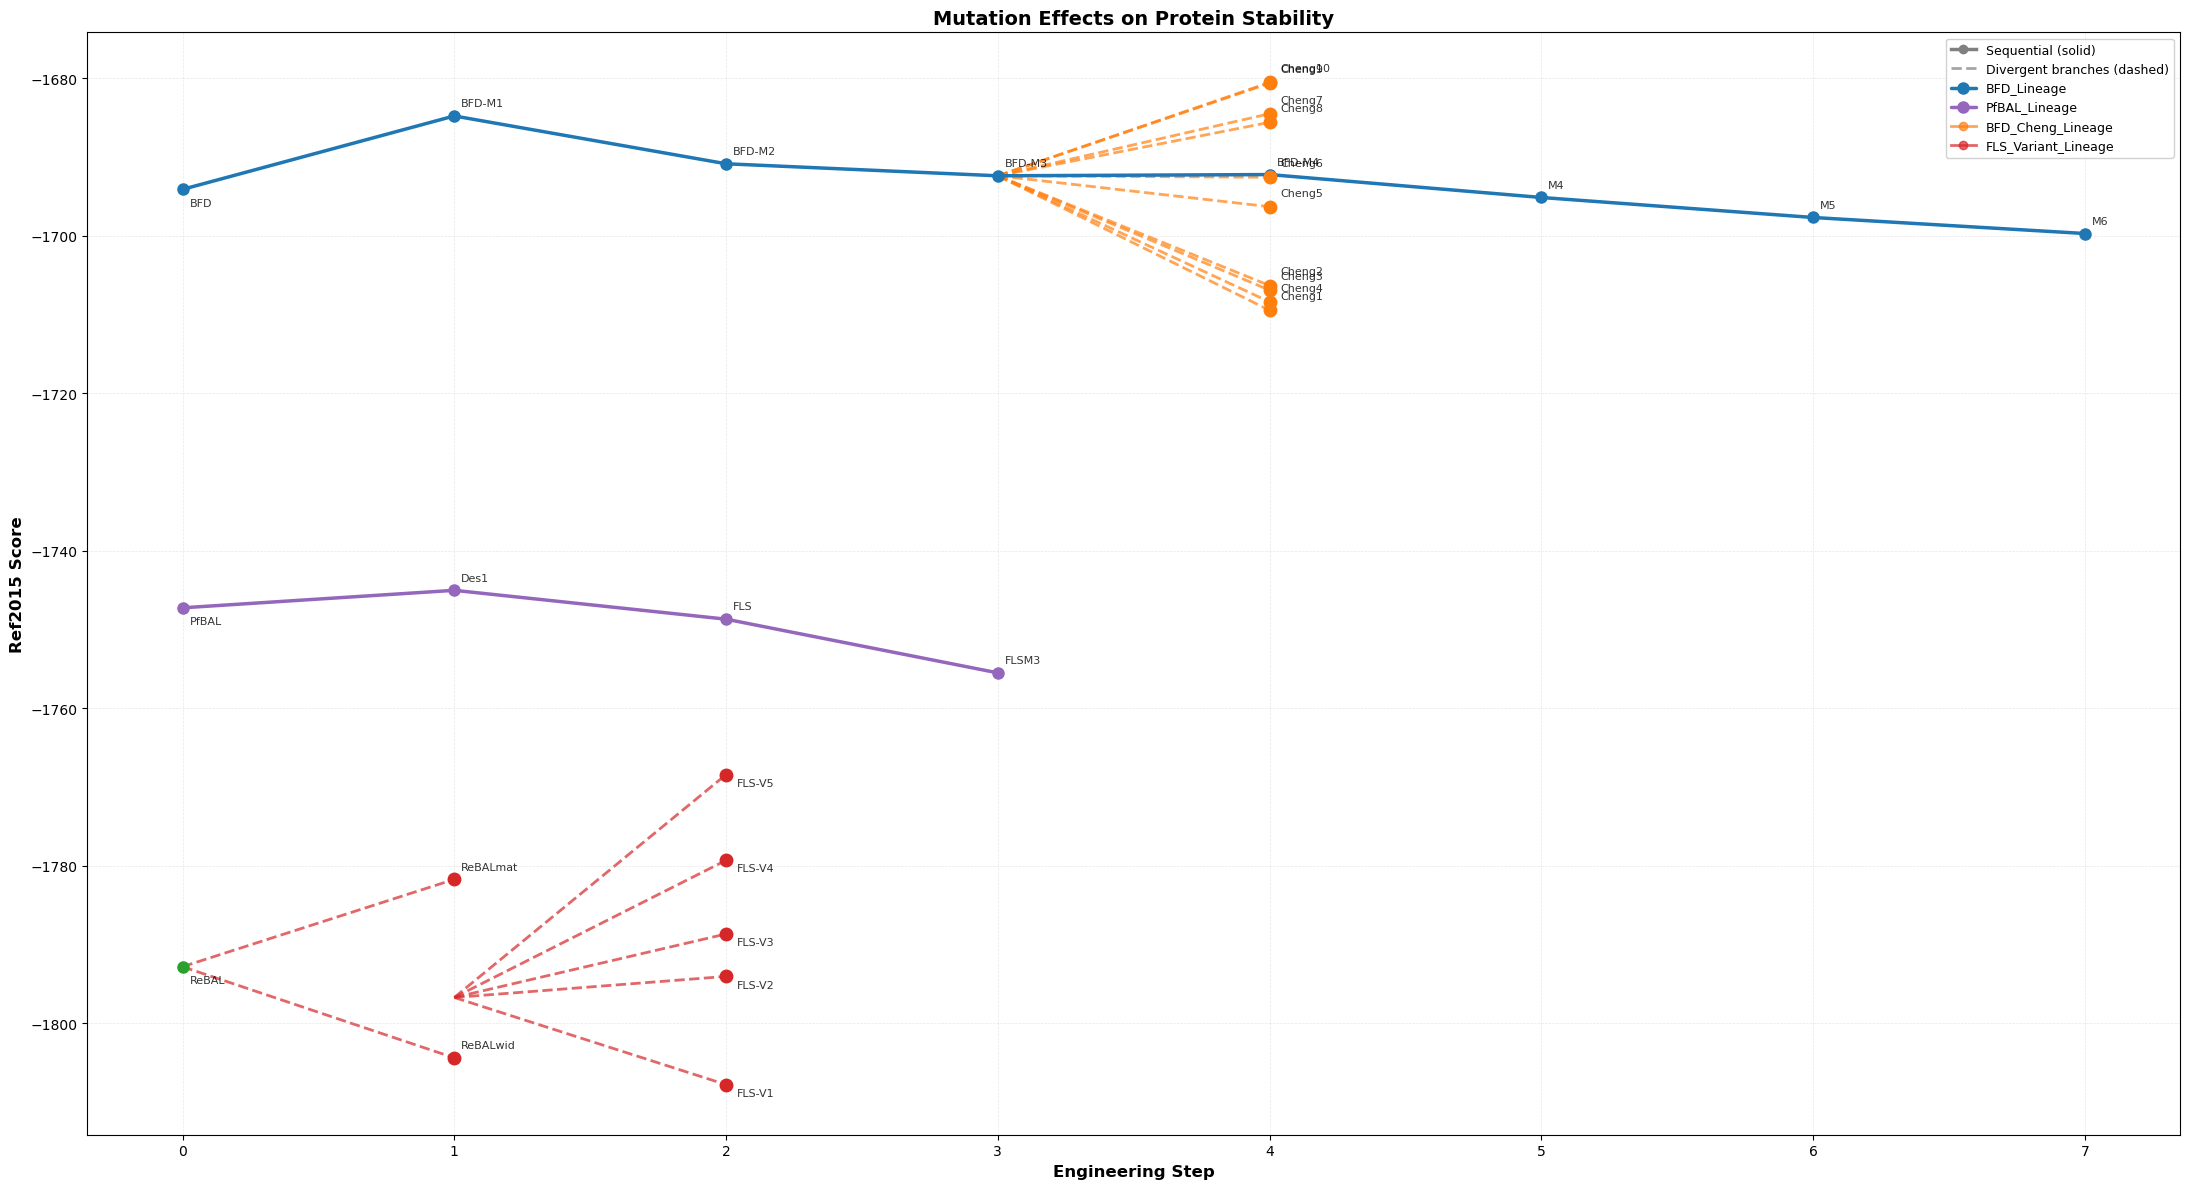


=== Branching Summary ===


From BFD-M3 (step 3, score -1692.40):
  → Cheng1 (step 4): -1694.48 (↓-2.08)
  → Cheng2 (step 4): -1694.66 (↓-2.26)
  → Cheng3 (step 4): -1698.59 (↓-6.19)
  → Cheng4 (step 4): -1703.41 (↓-11.01)
  → Cheng5 (step 4): -1694.66 (↓-2.26)
  → Cheng6 (step 4): -1694.25 (↓-1.85)
  → Cheng7 (step 4): -1689.52 (↑+2.88)
  → Cheng8 (step 4): -1693.94 (↓-1.54)
  → Cheng9 (step 4): -1692.31 (↑+0.09)
  → Cheng10 (step 4): -1695.55 (↓-3.15)

From ReBALmat (step 1, score -1796.72):
  → FLS-V1 (step 2): -1792.79 (↑+3.94)
  → FLS-V2 (step 2): -1786.55 (↑+10.17)
  → FLS-V3 (step 2): -1788.66 (↑+8.07)
  → FLS-V4 (step 2): -1786.81 (↑+9.92)
  → FLS-V5 (step 2): -1783.43 (↑+13.30)

From ReBAL (step 0, score -1792.82):
  → ReBALwid (step 1): -1789.39 (↑+3.43)
  → ReBALmat (step 1): -1796.72 (↓-3.91)


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

# Load your CSV
csv_path = "/home/myrsini/FLS-analysis/correct_variant_performance.csv" 
df = pd.read_csv(csv_path)

# Use the correct columns
df["score"] = pd.to_numeric(df["score"], errors="coerce")
df = df.dropna(subset=["score"])

# Get unique variants with their steps and scores
variant_data = df[['enzyme', 'step', 'score']].drop_duplicates(subset=['enzyme'])
print(f"Loaded {len(variant_data)} unique variants")

# Define branching relationships
branching_relationships = {
    'BFD-M3': ['Cheng1', 'Cheng2', 'Cheng3', 'Cheng4', 'Cheng5', 
               'Cheng6', 'Cheng7', 'Cheng8', 'Cheng9', 'Cheng10'],
    'ReBAL': ['ReBALwid', 'ReBALmat'],
    'ReBALmat': ['FLS-V1', 'FLS-V2', 'FLS-V3', 'FLS-V4', 'FLS-V5']
}

# Define sequential paths - ONLY linear sequences without branching
sequential_paths = {
    'BFD_Lineage': {
        'color': '#1f77b4',
        'variants': ['BFD', 'BFD-M1', 'BFD-M2', 'BFD-M3', 'BFD-M4', 'M4', 'M5', 'M6']
    },
    'PfBAL_Lineage': {
        'color': '#9467bd',
        'variants': ['PfBAL', 'Des1', 'FLS', 'FLSM3']
    }
    # ReBAL is NOT in sequential paths - it will be handled by branching only
}

# Create dictionaries for quick lookup
score_dict = variant_data.set_index('enzyme')['score'].to_dict()
step_dict = variant_data.set_index('enzyme')['step'].to_dict()

# Filter to existing variants
for lineage in sequential_paths:
    existing = [v for v in sequential_paths[lineage]['variants'] if v in score_dict]
    sequential_paths[lineage]['variants'] = existing

for parent in list(branching_relationships.keys()):
    if parent not in score_dict:
        print(f"Warning: Parent {parent} not found")
        continue
    children = [c for c in branching_relationships[parent] if c in score_dict]
    branching_relationships[parent] = children

# Create the plot
plt.figure(figsize=(22, 12))

# Store plotted positions
plotted_positions = {}  # variant -> (x, y)
all_points = {}  # for labels
step_offsets = defaultdict(list)

# Keep track of which branch legends we've added
added_branches = set()

# ==============================================
# PART 1: Plot starting points not in sequential paths
# ==============================================
# Plot ReBAL as a starting point
if 'ReBAL' in score_dict and 'ReBAL' in step_dict:
    x = step_dict['ReBAL']
    y = score_dict['ReBAL']
    plt.plot(x, y, 'o', color='#2ca02c', markersize=8, zorder=2)
    plotted_positions['ReBAL'] = (x, y)
    all_points['ReBAL'] = (x, y)
    step_offsets[x].append(('ReBAL', y))

# ==============================================
# PART 2: Plot sequential paths (these have no offsets)
# ==============================================
for lineage_name, data in sequential_paths.items():
    variants = data['variants']
    if len(variants) < 2:
        # For single-point lineages (none in this case, but keeping for flexibility)
        for variant in variants:
            if variant in step_dict and variant in score_dict:
                x = step_dict[variant]
                y = score_dict[variant]
                plt.plot(x, y, 'o', color=data['color'], markersize=8, zorder=2)
                plotted_positions[variant] = (x, y)
                all_points[variant] = (x, y)
                step_offsets[x].append((variant, y))
        continue
    
    steps = []
    scores = []
    for variant in variants:
        if variant in step_dict and variant in score_dict:
            x = step_dict[variant]
            y = score_dict[variant]
            steps.append(x)
            scores.append(y)
            plotted_positions[variant] = (x, y)
            all_points[variant] = (x, y)
            step_offsets[x].append((variant, y))
    
    plt.plot(steps, scores, 'o-', color=data['color'], 
            linewidth=2.5, markersize=8, label=lineage_name,
            solid_capstyle='round', zorder=2)

# ==============================================
# PART 3: Plot branching relationships
# ==============================================
for parent, children in branching_relationships.items():
    if parent not in score_dict or parent not in step_dict:
        continue
    
    # Get parent's plotted position
    if parent not in plotted_positions:
        print(f"Warning: Parent {parent} not found in plotted_positions")
        parent_x = step_dict[parent]
        parent_y = score_dict[parent]
    else:
        parent_x, parent_y = plotted_positions[parent]
    
    # Group children by step
    children_by_step = defaultdict(list)
    for child in children:
        if child in step_dict and child in score_dict:
            children_by_step[step_dict[child]].append(child)
    
    # Determine color for this branch
    if parent == 'BFD-M3':
        branch_color = '#ff7f0e'
        branch_name = 'BFD_Cheng_Lineage'
    else:
        branch_color = '#d62728'
        branch_name = 'FLS_Variant_Lineage'
    
    # Plot each group
    for step, children_at_step in children_by_step.items():
        num_children = len(children_at_step)
        
        if num_children == 1:
            y_offsets = [0]
        else:
            y_spread = 15  # Adjust this value to control spread
            y_offsets = np.linspace(-y_spread, y_spread, num_children)
        
        for child, y_offset in zip(children_at_step, y_offsets):
            child_x = step
            child_y = score_dict[child] + y_offset
            
            # Store plotted position
            plotted_positions[child] = (child_x, child_y)
            all_points[child] = (child_x, child_y)
            step_offsets[step].append((child, child_y))
            
            # Draw dashed line from parent's plotted position to child's plotted position
            plt.plot([parent_x, child_x], [parent_y, child_y], 
                    '--', color=branch_color, linewidth=2, alpha=0.7, zorder=1)
            
            # Plot child point
            plt.plot(child_x, child_y, 'o', color=branch_color, 
                    markersize=9, zorder=3)
    
    # Add legend entry for this branch (only once)
    if branch_name not in added_branches:
        plt.plot([], [], 'o-', color=branch_color, linewidth=2, 
                markersize=6, label=branch_name, alpha=0.7)
        added_branches.add(branch_name)

# ==============================================
# PART 4: Add labels
# ==============================================
for variant, (x, y) in all_points.items():
    label = variant
    
    # Default positioning
    if variant in ['BFD', 'ReBAL', 'PfBAL']:
        xytext = (5, -12)
    elif variant.startswith('Cheng'):
        xytext = (8, 8)
    elif variant.startswith('FLS-V'):
        xytext = (8, -8)
    else:
        xytext = (5, 7)
    
    plt.annotate(label, xy=(x, y), xytext=xytext, 
                textcoords='offset points', fontsize=8, 
                alpha=0.8, rotation=0, zorder=4, bbox=None)

# ==============================================
# PART 5: Customize plot
# ==============================================
plt.xlabel("Engineering Step", fontsize=12, fontweight='bold')
plt.ylabel("Ref2015 Score", fontsize=12, fontweight='bold')
plt.title("Mutation Effects on Protein Stability", 
          fontsize=14, fontweight='bold')

# Set x-axis to show all steps clearly
plt.xticks(range(int(min(step_dict.values())), int(max(step_dict.values())) + 1))

# Legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='gray', lw=2.5, linestyle='-', marker='o', markersize=6, label='Sequential (solid)'),
    Line2D([0], [0], color='gray', lw=2, linestyle='--', alpha=0.7, label='Divergent branches (dashed)'),
]

handles, labels = plt.gca().get_legend_handles_labels()
for handle, label in zip(handles, labels):
    legend_elements.append((handle, label))

unique_legend = {}
for item in legend_elements:
    if isinstance(item, tuple):
        if item[1] not in unique_legend:
            unique_legend[item[1]] = item[0]
    else:
        if item.get_label() not in unique_legend:
            unique_legend[item.get_label()] = item

plt.legend(handles=unique_legend.values(), labels=unique_legend.keys(), 
          loc='best', fontsize=9, framealpha=0.9)
plt.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

# Print summary
print("\n=== Branching Summary ===\n")
for parent, children in branching_relationships.items():
    if parent in score_dict:
        print(f"\nFrom {parent} (step {step_dict[parent]}, score {score_dict[parent]:.2f}):")
        for child in children:
            if child in score_dict:
                delta = score_dict[child] - score_dict[parent]
                arrow = "↑" if delta > 0 else "↓"
                print(f"  → {child} (step {step_dict[child]}): {score_dict[child]:.2f} ({arrow}{delta:+.2f})")